<img title="Instituto Federal do Amazonas" alt="logo do IFAM" width="200" src='https://imgs.search.brave.com/7S6EabbIm2owts-ML11oCagljcO_OnAQik1wNzBZmU8/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly93d3cu/Z292LmJyL2lucGEv/cHQtYnIvaW5vdmFj/YW8vaW1hZ2Vucy9s/b2dvcy1leHRlcm5h/cy9pZmFtLnBuZy9A/QGltYWdlcy9pbWFn/ZS5wbmc'>

# Instituto Federal de Educação, Ciência e Tecnologia do Amazonas
## Bacharelado em Ciências da Computação
### Programação para análise de dados
#### Gabriele Silva
#### Victoria Maciel


---

1.  Definição e Validação dos Schemas

2. Operações em Grandes Volumes de dados, incrementado gradativamente
 
2.1 - Horas

2.2 - Dias

2.3 - Semanas

2.4 - Meses

2.5 - Trimestres

2.6 - Semestres

2.7 - Anos

2.8 - Limite Máximo do Dataset

> * Operações de Consultas, com agrupamentos e Geração de Gráficos 

3. Comparação de Desempenho, envolvendo as bibliotecas utilizadas em sala

3.1 - Pandas

3.2 - PyArrow

3.3 - Polars

3.4 - Dask


4. Processamento paralelo com Dask, utilizando pelo menos 3 máquinas (Físicas) diferentes e geração de relatórios de desempenho com variações de numero de workers. Também fazer com aumento gradual, como por exemplo: 1
1 máquina

2 máquinas 

3 máquinas

**{ as três variar de 2 a N workers }**

In [1]:
# pip install pandera

In [2]:
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as py
import pyarrow.compute as pc

from fastparquet import ParquetFile

import pandera as pa
import time 
import psutil

import dask.dataframe as dd

from scipy import stats
from scipy.stats import probplot
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpaches
import seaborn as sns
import numpy as np

import requests
import zipfile
import io

import polars as pl
import polars.selectors as cs  # Seletores para facilitar a vida
import matplotlib.pyplot as plt

import gc

import os, warnings
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'
warnings.filterwarnings('ignore')
n_amostra = 500_000

In [3]:
n_amostra = 500_000
fim_anos = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

for i in fim_anos:
    
    url = f'https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINASC/csv/SINASC_20{i}_csv.zip'
    
    arquivo_local = None
    url_natalidade = url
    
    fonte = arquivo_local if (arquivo_local and Path(arquivo_local).exists()) else url_natalidade
    print(f'Fonte configurada: {fonte[:80]}...' if len(fonte)>80 else f'Fonte: {fonte}')
    
    
    # Download do arquivo bruto - conteúdo binário
    resposta_da_requisicao = requests.get(url_natalidade)
    conteudo_do_arquivo = io.BytesIO(resposta_da_requisicao.content)
    
    # "Des"compactação e leitura
    with zipfile.ZipFile(conteudo_do_arquivo) as zippado:
        arquivos_internos = zippado.namelist()
        with zippado.open(arquivos_internos[0]) as f:
            df_natalidade = pd.read_csv(f, sep=';', nrows=n_amostra, encoding='latin1', low_memory=False)
            
    # Validação da Compressão
    compressao = "ZIP" if fonte.endswith('.zip') else "Nenhuma"
    
    # Verificação dos metadados
    uso_memoria = df_natalidade.memory_usage(deep=True) / 1024
    print(f'{"Coluna":<21}|{"Tipo":<12}|{"RAM":<5}')
    print(f'{"_"*50}')
    for meta in df_natalidade.columns:
        tipo = str(df_natalidade[meta].dtype)
        espaco = uso_memoria[meta]
        print(f' {meta:<20}| {tipo:<10} |{espaco:>12.1f}')
    print(f'{"_"*50}')
    print('')
    
    
    # Separação das principais colunas para análise
    lista_colunas_principais = [
        #PAIS
        'IDADEMAE',
        'IDADEPAI',
    
        #GESTAÇÃO
        'SEMAGESTAC', #SEMANAS DE GESTAÇÃO
        'QTDPARTNOR', #QUANTIDADE DE PARTOS NORMAIS
        'QTDPARTCES', #QUANTIDADE DE PARTOS CESÁRIOS
        'CONSPRENAT', #QUANTIDADE DE PRENATAIS FEITOS.
        'KOTELCHUCK', #INDICE QUE CLASSIFICA A QUALIDADE DO PRENATAL FEITO
        'DIFDATA', #Diferença de dias entre o nascimento e o registro.
        'GRAVIDEZ', #INDICA SE A GRAVIDEZ FOI SIMPLES, DUPLA, TRIPLA E ETC.
    
        #BEBÊ E NASCIMENTO
        'PESO',
        'HORANASC',
        'DTNASC',
        'SEXO'
    ]
    
    df_natalidade.columns = df_natalidade.columns.str.upper()
    
    # Verificação dos metadados
    uso_memoria = df_natalidade.memory_usage(deep=True) / 1024
    print(f'{"Coluna":<21}|{"Tipo":<12}|{"RAM":<5}')
    print(f'{"_"*50}')
    for meta in df_natalidade.columns:
        tipo = str(df_natalidade[meta].dtype)
        espaco = uso_memoria[meta]
        print(f' {meta:<20}| {tipo:<10} |{espaco:>12.1f}')
    print(f'{"_"*50}')
    print('')
    
    # Organizando um novo dataframe com as colunas
    df_final = df_natalidade[lista_colunas_principais].copy()
    
    #transformando em .parquet
    df_final.to_parquet(f'sinasc20{i}_reduzidissima_final.parquet', index=False)
    print(f'Arquivo sinasc20{i}_reduzidissima_final.parquet salvo com sucesso!!!')
    print(f'{"*"*120}\n')
    
    del df_natalidade
    del resposta_da_requisicao
    del conteudo_do_arquivo
    gc.collect()

tabelas = []
path = '/home/aluno/Downloads/'

for i in fim_anos:
    arquivo = pq.read_table(f"{path}sinasc20{i}_reduzidissima_final.parquet")
    tabelas.append(arquivo)

df_finalissimo = py.concat_tables(tabelas, promote_options="permissive")
pq.write_table(df_finalissimo, 'sinasc_reduzidissima_final.parquet')

print(f'Arquivo sinasc_reduzidissima_final.parquet salvo com sucesso!!!')
print(f'{"*"*120}\n')

del tabelas

gc.collect()

Fonte configurada: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINASC/csv/SINASC_2015_csv....
Coluna               |Tipo        |RAM  
__________________________________________________
 CONTADOR            | int64      |      3906.2
 ORIGEM              | int64      |      3906.2
 CODESTAB            | float64    |      3906.2
 CODMUNNASC          | int64      |      3906.2
 LOCNASC             | int64      |      3906.2
 IDADEMAE            | float64    |      3906.2
 ESTCIVMAE           | float64    |      3906.2
 ESCMAE              | float64    |      3906.2
 CODOCUPMAE          | float64    |      3906.2
 QTDFILVIVO          | float64    |      3906.2
 QTDFILMORT          | float64    |      3906.2
 CODMUNRES           | int64      |      3906.2
 GESTACAO            | float64    |      3906.2
 GRAVIDEZ            | float64    |      3906.2
 PARTO               | float64    |      3906.2
 CONSULTAS           | float64    |      3906.2
 DTNASC              | int64      |  

0

In [4]:
df_finalissimo.to_pandas()

,IDADEMAE,IDADEPAI,SEMAGESTAC,QTDPARTNOR,QTDPARTCES,CONSPRENAT,KOTELCHUCK,DIFDATA,GRAVIDEZ,PESO,HORANASC,DTNASC,SEXO
0,31.0,NaN,NaN,NaN,NaN,NaN,9,50,1.0,2900.0,1730.0,8012015,2
1,28.0,NaN,NaN,NaN,NaN,NaN,9,147,1.0,4150.0,815.0,3022015,2
2,26.0,NaN,NaN,NaN,NaN,NaN,9,138,1.0,3490.0,800.0,12022015,2
3,21.0,NaN,NaN,NaN,NaN,NaN,9,29,1.0,3200.0,835.0,31032015,1
4,18.0,NaN,NaN,NaN,NaN,NaN,9,15,1.0,3200.0,2119.0,14042015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,21.0,NaN,40.0,0.0,0.0,13.0,5,31,1.0,3235.0,1137.0,29062024,1
4999996,36.0,NaN,39.0,0.0,1.0,14.0,5,31,1.0,3905.0,1451.0,29062024,1
4999997,31.0,NaN,31.0,0.0,1.0,8.0,5,30,1.0,1820.0,1803.0,30062024,2
4999998,26.0,NaN,41.0,1.0,0.0,9.0,5,30,1.0,3750.0,1521.0,30062024,1


---

# 1. Definição e Validação dos Schemas

In [5]:
tabela_de_comparacao = []

In [6]:
schema = pa.DataFrameSchema({
    'IDADEMAE': pa.Column(
        float, #dtype
        description = 'Idade da mãe do Recém Nascido.',
        nullable=True, # nullable=False: Proíbe valores vazios (NaN)
        checks=[pa.Check.gt(0), pa.Check.lt(100)],
        coerce=True
    ),
    'IDADEPAI': pa.Column(
        float, #dtype
        description = 'Idade da pai do Recém Nascido.',
        nullable = True, # nullable=False: Proíbe valores vazios (NaN)
        checks=[pa.Check.gt(0), pa.Check.lt(100)],
        coerce=True
    ),
    'SEMAGESTAC':pa.Column(
        int, #dtype
        description = 'Quantidade de semanas da gestação.',           
        nullable=True , # nullable=False: Proíbe valores vazios (NaN)
        checks=[pa.Check.gt(4), pa.Check.lt(46)],
        coerce=True
    ),
    'QTDPARTNOR':pa.Column(
        int,
        description = 'Quantidade de partos normais antes do nascimento do bebê em questão.',
        nullable = False,
        checks = pa.Check.gt(-1),
        coerce = True
    ),
    'QTDPARTCES': pa.Column(
        int,
        description = 'Quantidade de partos cesarianos antes do nascimento do bebê em questão.',
        nullable = False,
        checks = pa.Check.gt(-1),
        coerce = True
    ),
    'CONSPRENAT': pa.Column(
        int,
        description = 'Quantidade de consultas prenatais feitas.',
        nullable = False,
        checks=[pa.Check.gt(-1), pa.Check.lt(100)],
        coerce = True
    ),
    'KOTELCHUCK': pa.Column(
        int,
        description = 'Índice de Adequação do Uso de Cuidados Pré-Natais (APNCU) - Avalia a qualidade do acompanhamento médico durante a gravidez.', #Quando o pré-natal começou e quantas consultas foram feitas em relação ao esperado para a idade gestacional.'
        nullable = False,
        checks=[pa.Check.gt(0), pa.Check.lt(10)],
        coerce = True        
    ),
    'DIFDATA': pa.Column(
        int,
        description = 'Diferença entre a data de registro da criança e data de nascimento.',
        nullable = False,
        checks = pa.Check.gt(-1),
        coerce = True
    ),
    'GRAVIDEZ': pa.Column(
        int,
        description = 'Indica se a gravidez foi simples, dupla, tripla e etc.',
        checks = pa.Check.isin([1,2,3,9]),
        coerce = True
    ),
    'PESO': pa.Column(
        float,
        description = 'Peso em gramas do recém-nascido.',
        checks=[pa.Check.gt(0), pa.Check.lt(7100.0)],
        coerce = True
    ),
    'HORANASC': pa.Column(
        "datetime64[ns]",
        description='Hora do nascimento do bebê',          
        nullable=True            
    ),
    'DTNASC': pa.Column(
        "datetime64[ns]", 
        description='Data de nascimento do bebê',
    ),
    'DATA_HORA_NASC': pa.Column(
        "datetime64[ns]",
        description='Data e hora combinadas do nascimento',
        nullable=True
    ),
    'SEXO': pa.Column(
        int,
        description = 'Sexo do recém-nascido',
        checks = pa.Check.isin([0,1,2]),
        nullable = False,
        coerce = True
    )
})

> Pyarrow

In [7]:
def limpeza_pyarrow(batch):
    colunas = [c for c in batch.schema.names if c not in ['IDADEPAI', 'IDADEMAE']]
    
    for col in colunas:
        batch = batch.filter(pc.is_valid(batch.column(col)))

    batch = batch.filter(pc.greater(batch.column('PESO'), 0))

    # Convertemos para string e removemos possíveis ".0" (comum se vier de float)
    dtnasc = batch.column('DTNASC').cast(py.string())
    dtnasc_limpo = pc.replace_substring(dtnasc, pattern=".0", replacement="")
    dtnasc_correto = pc.utf8_lpad(dtnasc_limpo, width=8, padding='0')
    
    hora = batch.column('HORANASC').cast(py.string())
    hora_limpo = pc.replace_substring(hora, pattern=".0", replacement="")
    hora_correta = pc.utf8_lpad(hora_limpo, width=4, padding='0')

    data_hora_str = pc.binary_join_element_wise(dtnasc_correto, hora_correta, " ")
    
    try:
        data_hora_full = pc.strptime(data_hora_str, format='%d%m%Y %H%M', unit='s')
        
    except py.ArrowInvalid:
        # Fallback caso algum dado esteja muito fora do padrão
        data_hora_full = py.array([None] * batch.num_rows, type = py.timestamp('s'))

    dtnasc_data = pc.strptime(dtnasc_correto, format='%d%m%Y', unit='s', error_is_null=True)
    hora_data = pc.strptime(hora_correta, format='%H%M', unit='s', error_is_null=True)
    data_hora_full = pc.strptime(data_hora_str, format='%d%m%Y %H%M', unit='s', error_is_null=True)

    idx_dtnasc = batch.schema.get_field_index('DTNASC')
    batch = batch.set_column(idx_dtnasc, 'DTNASC', dtnasc_data)

    idx_hrnasc = batch.schema.get_field_index('HORANASC')
    batch = batch.set_column(idx_hrnasc, 'HORANASC', hora_data)

    return batch.append_column('DATA_HORA_NASC', data_hora_full)

In [8]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

path = '/home/aluno/Downloads/'
arquivo = pq.read_table(f"{path}sinasc_reduzidissima_final.parquet")

print("Iniciando validação por lotes com PyArrow...")
print(f'{"*"*50}\n')

lotes_validados = []

try:
    for batch in arquivo.to_batches(max_chunksize=n_amostra):
        batch_limpo = limpeza_pyarrow(batch)
        df_para_validar = batch_limpo.to_pandas() 
        schema.validate(df_para_validar)

        tabela_lote = py.Table.from_pandas(df_para_validar)
        lotes_validados.append(tabela_lote)
        tabela_final = py.concat_tables(lotes_validados)
       
        print(f"Lote de {batch_limpo.num_rows} linhas processado!")

except Exception as e:
    print(f"❌ Erro: {e}")
    
fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pyarrow",
        "Ação" : "Leitura e Validação do Schema",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
print(f"Tabela final gerada com {tabela_final.num_rows} linhas!")
print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

Iniciando validação por lotes com PyArrow...
**************************************************

Lote de 88675 linhas processado!
Lote de 95879 linhas processado!
Lote de 91110 linhas processado!
Lote de 91396 linhas processado!
Lote de 104920 linhas processado!
Lote de 92870 linhas processado!
Lote de 95696 linhas processado!
Lote de 98706 linhas processado!
Lote de 118963 linhas processado!
Lote de 98898 linhas processado!
Lote de 98243 linhas processado!
Lote de 99645 linhas processado!
Lote de 117901 linhas processado!
Lote de 96065 linhas processado!
Lote de 99360 linhas processado!
Lote de 110651 linhas processado!
Lote de 114246 linhas processado!
Lote de 108954 linhas processado!
Lote de 98762 linhas processado!
Lote de 123461 linhas processado!
Lote de 113199 linhas processado!
Lote de 103259 linhas processado!
Lote de 109076 linhas processado!
Lote de 128229 linhas processado!
Lote de 109679 linhas processado!
Lote de 108561 linhas processado!
Lote de 114339 linhas processado

> polars

In [9]:
def limpeza_polars(batch):
    colunas = [c for c in batch.columns if c not in ['IDADEPAI', 'IDADEMAE']]
    batch = batch.drop_nulls(subset = colunas)
    batch = batch.filter(pl.col("PESO") > 0)

    batch = batch.with_columns(
        pl.col("DTNASC").cast(pl.Utf8).str.replace_all(r"\.0$", "").str.pad_start(8, '0').alias("DTNASC_STR"),
        pl.col("HORANASC").cast(pl.Utf8).str.replace_all(r"\.0$", "").str.pad_start(4, '0').alias("HORANASC_STR")
    )
    
    batch = batch.with_columns(
        pl.col("DTNASC_STR").str.strptime(pl.Datetime, format="%d%m%Y", strict=False).alias("DTNASC"),
        pl.col("HORANASC_STR").str.strptime(pl.Datetime, format="%H%M", strict=False).alias("HORANASC"),
        
        pl.concat_str([pl.col("DTNASC_STR"), pl.col("HORANASC_STR")], separator=" ")
        .str.strptime(pl.Datetime, format="%d%m%Y %H%M", strict=False)
        .alias("DATA_HORA_NASC")
    )
    
    batch = batch.drop_nulls(subset = colunas + ["DATA_HORA_NASC"])
    batch = batch.drop(["DTNASC_STR", "HORANASC_STR"])

    return batch

In [10]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

df_polars = pl.scan_parquet(f"{path}sinasc_reduzidissima_final.parquet")

print("Iniciando validação por lotes com Polars...")
print(f'{"*"*50}\n')

total_linhas = df_polars.select(pl.len()).collect().item()

for i in range(0, total_linhas, n_amostra):
    df_batch = df_polars.slice(i, n_amostra).collect()
    try:
        df_validar = limpeza_polars(df_batch)
        df_limpo_pandas = df_validar.to_pandas()
        schema.validate(df_limpo_pandas)
        df_polars_novo = pl.from_pandas(df_limpo_pandas)
    except Exception as e:
        print(f"❌ Erro no bloco {i}: {e}")
    
    print(f"Lote de {len(df_limpo_pandas)} linhas processado!")

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Polars",
        "Ação" : "Leitura e Validação do Schema",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

Iniciando validação por lotes com Polars...
**************************************************

Lote de 352618 linhas processado!
Lote de 374221 linhas processado!
Lote de 391888 linhas processado!
Lote de 397229 linhas processado!
Lote de 414381 linhas processado!
Lote de 429468 linhas processado!
Lote de 437153 linhas processado!
Lote de 453615 linhas processado!
Lote de 457950 linhas processado!
Lote de 465635 linhas processado!
**************************************************

Tempo total de processamento: 2.01s
**************************************************

Memória inicial: 2548.80 MB
Memória final: 3398.87 MB
Memória total utilizada no processo: 850.07 MB
**************************************************



> Dask

In [11]:
#pip install dask

In [12]:
def Limpeza_Dask(df_dask):
    colunas_para_limpar = df_dask.columns.difference(['IDADEPAI', 'IDADEMAE'])
    df_dask = df_dask.dropna(subset=colunas_para_limpar)
    df_dask = df_dask[df_dask['PESO'] > 0]
    
    df_dask['DTNASC'] = df_dask['DTNASC'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(8)
    df_dask['DTNASC'] = dd.to_datetime(df_dask['DTNASC'], format='%d%m%Y', errors='coerce')
    
    hr_str = df_dask['HORANASC'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(4)
    temp_hora = dd.to_datetime(hr_str, format='%H%M', errors='coerce')
    
    df_dask['DATA_HORA_NASC'] = df_dask['DTNASC'] + \
                                dd.to_timedelta(temp_hora.dt.hour, unit='h') + \
                                dd.to_timedelta(temp_hora.dt.minute, unit='m')
    
    df_dask['HORANASC'] = temp_hora
    
    ddf_limpo = df_dask.dropna(subset=['DTNASC', 'DATA_HORA_NASC'])
    
    return df_dask

In [13]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

df_dask = dd.read_parquet(f"{path}sinasc_reduzidissima_final.parquet")

print("Iniciando validação do schema 'com Dask'...")
print(f'{"*"*50}\n')

ddf_limpo = Limpeza_Dask(df_dask)

try:
    schema.validate(ddf_limpo)    
except pa.errors.SchemaError as e:
    print(f"❌ Erro de validação encontrado: {e}")

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Dask",
        "Ação" : "Leitura e Validação do Schema",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

Iniciando validação do schema 'com Dask'...
**************************************************

**************************************************

Tempo total de processamento: 0.03s
**************************************************

Memória inicial: 3398.87 MB
Memória final: 3399.45 MB
Memória total utilizada no processo: 0.58 MB
**************************************************



> Pandas

In [14]:
#pip install fastparquet

In [15]:
from fastparquet import ParquetFile

In [16]:
def Limpeza_pandas(df):
    colunas_para_limpar = df.columns.difference(['IDADEPAI', 'IDADEMAE'])
    df = df.dropna(subset=colunas_para_limpar)

    df = df[df['PESO'] > 0]

    df['DTNASC'] = pd.to_datetime(
        df['DTNASC'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(8),
        format='%d%m%Y',
        errors='coerce'
    )

    hora = df['HORANASC'] = pd.to_datetime(
        df['HORANASC']
            .astype(str)
            .str.replace(r'\.0$', '', regex=True)
            .str.zfill(4),
        format='%H%M',
        errors='coerce'
    )

    df['DATA_HORA_NASC'] = df['DTNASC'] + (
        hora - hora.dt.normalize()
    )

    df = df.dropna(subset=['DTNASC', 'DATA_HORA_NASC'])

    return df


In [17]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

file_name = f"{path}sinasc_reduzidissima_final.parquet"

print("Iniciando validação com Pandas...")
print(f'{"*"*50}\n')

pf = ParquetFile(file_name)
tamanho = pf.count()
print(f'{tamanho}')
for chunk in pf.iter_row_groups():
    df_processado = Limpeza_pandas(chunk)
    try:
        schema.validate(df_processado)
    except pa.errors.SchemaError as e:
        print(f"❌ Erro de validação: {e}")
        
fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pandas",
        "Ação" : "Leitura e Validação do Schema",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

Iniciando validação com Pandas...
**************************************************

5000000
**************************************************

Tempo total de processamento: 18.95s
**************************************************

Memória inicial: 3399.51 MB
Memória final: 4080.05 MB
Memória total utilizada no processo: 680.54 MB
**************************************************



---

# 2. Operações em Grandes Volumes de dados, incrementado gradativamente

In [18]:
# pip install seaborn

In [19]:
estilo_titulo = {
    'family': 'serif',
    'color':  'firebrick',
    'weight': 'bold',
    'size': 18
}

COR_PRINCIPAL = '#2E75B6'
COR_DESTAQUE = '#C62828'
COR_MEDIA = '#E65100' #laranja
COR_MEDIANA = '#2E7D32' # verde
COR_IQR = '#6A1B9A' # roxo
COR_DESVIO = '#AD1457' # rosa

In [20]:
intervalos_iniciais = [
    pd.Timedelta(hours=12),   # 2.1 - 12 Horas
    pd.Timedelta(days=1),    # 2.2 - 1 Dia
]

intervalos_medianos = [
    pd.Timedelta(weeks=1),      # 2.3 - 1 Semana
    pd.offsets.MonthBegin(1),   # 2.4 - 1 Mês (Lógica de calendário)
]

intervalos_finais = [
    pd.offsets.QuarterBegin(1), # 2.5 - 1 Trimestre
    pd.offsets.SemiMonthEnd(12),# 2.6 - 1 Semestre (ou 6 * MonthBegin)
]

intervalos_alemDoFim = [
    pd.offsets.YearBegin(1),    # 2.7 - 1 Ano
    pd.offsets.YearBegin(10),   # 2.8 - Limite (Aprox. 522 semanas = 10 anos)
]

In [26]:
def formatar_tempo(tempo):
    if isinstance(tempo, pd.Timedelta):
        if tempo.days >= 1:
            return f"{tempo.days} dia(s)"
        else:
            horas = tempo.total_seconds() / 3600
            return f"{int(horas)} hora(s)"
    
    elif isinstance(tempo, pd.offsets.YearBegin):
        return f"{tempo.n} ano(s)"
    
    elif isinstance(tempo, pd.offsets.MonthBegin):
        return f"{tempo.n} mês(es)"
    
    elif isinstance(tempo, pd.offsets.QuarterBegin):
        return f"{tempo.n} trimestre(s)"
    
    elif isinstance(tempo, pd.offsets.SemiMonthEnd):
        return f"{tempo.n//2} semestre(s)"
    
    else:
        return str(tempo)

> Pyarrow

In [27]:
def metricas(df_incremento, tempo):
    nomes_colunas = [
        campo.name for campo in df_incremento.schema 
        if py.types.is_integer(campo.type) or py.types.is_floating(campo.type)
    ]
    
    lista_stats = []
    
    for nome in nomes_colunas:
        dados_coluna = df_incremento.column(nome)
        
        stats_linha = {
            "Coluna": nome,
            "Média": round(pc.mean(dados_coluna).as_py() or 0, 2),
            "Soma": pc.sum(dados_coluna).as_py(),
            "Contagem": pc.count(dados_coluna).as_py(),
            "Mínimo": pc.min(dados_coluna).as_py(),
            "Máximo": pc.max(dados_coluna).as_py()
        }
        lista_stats.append(stats_linha)
    df_final = pd.DataFrame(lista_stats)
    
    altura = max(2, len(nomes_colunas) * 0.45)
    fig, ax = plt.subplots(figsize=(10, altura), facecolor='#f0f0f0') 
    ax.axis('off')
    
    tabela = ax.table(
        cellText=df_final.values, 
        colLabels=df_final.columns, 
        loc='center', 
        cellLoc='center'
    )
    
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.5) 
    
    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            
    tempo_formatado = formatar_tempo(tempo)
    plt.title(f"Métricas do Incremento em {tempo_formatado}", fontdict=estilo_titulo)
    plt.show()
    
    return lista_stats

In [28]:
def grafico_de_correlacao(df_incremento, tempo):
    df_incremento = df_incremento.to_pandas()
    
    colunas_selecionadas = ['CONSPRENAT', 'SEMAGESTAC', 'PESO', 'KOTELCHUCK'] 
    corr = df_incremento[colunas_selecionadas].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='OrRd', fmt=".2f")
    
    plt.title('Matriz de Correlação', fontdict = estilo_titulo)
    plt.show()

In [29]:
def grafico_de_sturges(df_incremento, tempo):
    
    serie = df_incremento['PESO'] 
    serie = serie.to_pandas()
    
    fig, ax   = plt.subplots(figsize =(6, 3))
    
    media   = serie.mean() # media
    mediana = serie.median() # mediana
    dp      = serie.std() # Mede a dispersão; quanto os dados variam em relação à média.
    q1      = serie.quantile(0.25) 
    q3      = serie.quantile(0.75)
    p99     = serie.quantile(0.99) # Valor que delimita os 1% maiores dados da série.
    skew    = serie.skew() # Mede a falta de simetria da distribuição.

    
    series_vis = serie[serie<= p99]
    n_fora    = (serie > p99).sum()

    
    #desvio padrão
    #avxspan - Define uma área de sombreamento
    # 1° linha: define o tamanho do sombreamento. (0, media-dp), onde começa e media + dp, one termina.
    # 2° linha: define a transparência da área.
    ax.axvspan(max(0, media - dp), media +dp,
               alpha = 0.08, color=COR_DESVIO,
               label = f'Media desv (desv = {dp:.2f})')
    ax.axvline(max(0, media - dp), color=COR_DESVIO, lw=1.2, ls=':') # define a linha de demarcação
    ax.axvline( (media + dp), color=COR_DESVIO, lw=1.2, ls=':') # define a linha de demarcação

    #IQR
    ax.axvspan(q1, q3, alpha = 0.12 ,color=COR_IQR,
               label = f'IQR: Q1 = {q1:.2f} - q3 = {q3:.2f}')
    ax.axvline(q1, color=COR_IQR, lw=1.4, ls=':')
    ax.axvline(q3, color=COR_IQR, lw=1.4, ls=':')
    
    #Medidas de localização
    ax.axvline(media, color =  'firebrick', lw = 2.4, ls="--", label=f'Média = {media:.2f}')
    ax.axvline(mediana, color =  COR_MEDIANA, lw = 2.4, ls="--", label=f'Mediana = {mediana:.2f}')

    
    ymax = ax.get_ylim()[1]
    
    #Mediana linha
    ax.annotate(f'Mediana\n {mediana:.2f}',
               xy=(mediana, ymax *0.72),
               xytext = (mediana - 18, ymax *0.92),
               color = COR_MEDIANA, fontsize =10, fontweight ='bold',
               ha = 'center',
               arrowprops = dict(arrowstyle = '->', color = COR_MEDIANA, lw=1.8),
               bbox = dict(boxstyle = 'round, pad=0.3', facecolor = 'white',
                                 edgecolor= COR_MEDIANA, alpha = 0.9),
    )

    #media linha
    ax.annotate(f'Media\n {media:.2f}',
               xy=(media, ymax *0.60),
               xytext = (media + 20, ymax *0.30),
               color = 'firebrick', fontsize =10, fontweight ='bold',
               ha = 'center',
               arrowprops = dict(arrowstyle = '->', color = 'firebrick', lw=1.8),
               bbox = dict(boxstyle = 'round, pad=0.3', facecolor = 'white',
                                 edgecolor= 'firebrick', alpha = 0.9),
    )
    
    # Fórmula de "sturges"
    n = len(serie)
    k = int(1 + 3.322 * np.log10(n))
    
    print(f"Número de classes (Sturges): {k}")
    
    # Histograma
    plt.hist(df_incremento['PESO'] , bins=k, color = 'salmon', edgecolor='red')
    plt.title(f"Histograma (Regra de Sturges)")
    plt.xlabel("Peso dos recém-nascidos em gramas")
    plt.ylabel(" ")
    plt.show()

    
    distancia = (serie.mean() - serie.median())
    assimetria = ''
    if (distancia > 0):
        assimetria = 'Assimetria à direita - POSITIVA!'
    elif(distancia < 0):
        assimetria = 'Assimetria à esquerda - NEGATIVA!'
    else:
        assimetria = 'Simétrica'
    
    print(f"Distância Média/Mediana: {distancia:.2f}\n"
          f'{assimetria}\n'
          f'{'_'*120}\n'
         )

In [30]:
def grafico_de_pizza(df_incremento, tempo):
    df_pd = df_incremento.to_pandas()
    
    contagem = df_pd.groupby('SEXO').size()
    contagem.index = contagem.index.map({1: 'Meninos', 2: 'Meninas'})
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    cores = ['#7FB3D5', 'salmon']

    ax.pie(contagem, 
           labels=contagem.index, 
           autopct='%1.1f%%', 
           startangle=90, 
           colors=cores,
           explode = [0.05] + [0]*(len(contagem)-1))
    
    ax.set_title(f"Proporção Meninos vs Meninas\n(Tempo: {tempo})")
    
    plt.show()

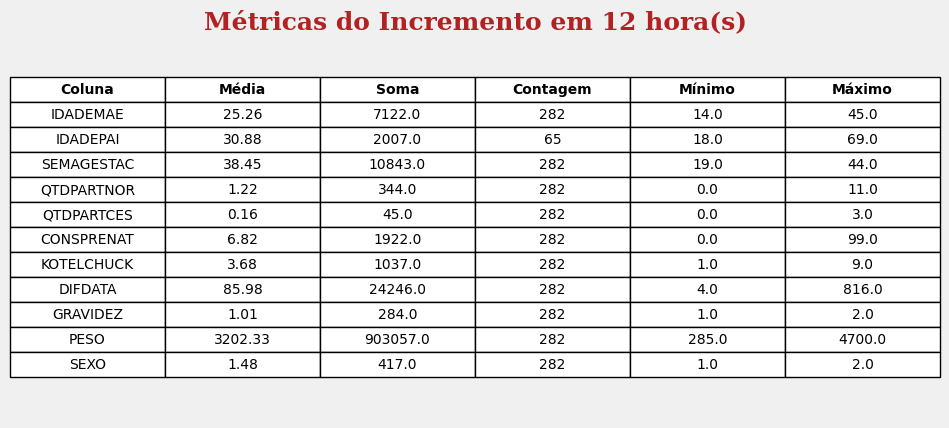

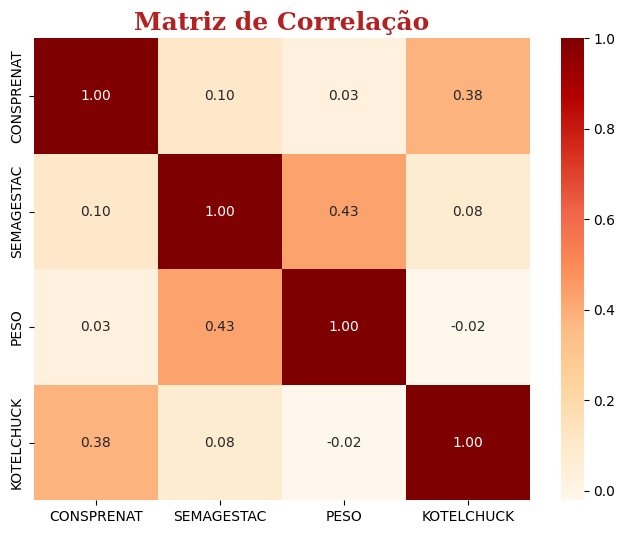

Número de classes (Sturges): 9


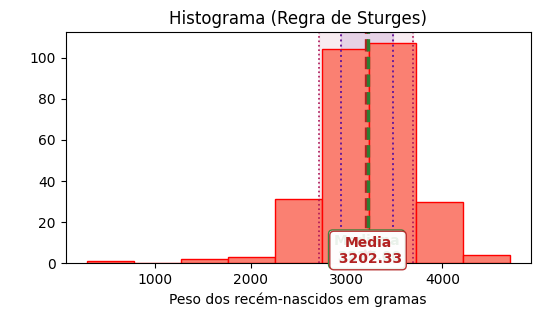

Distância Média/Mediana: -24.67
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



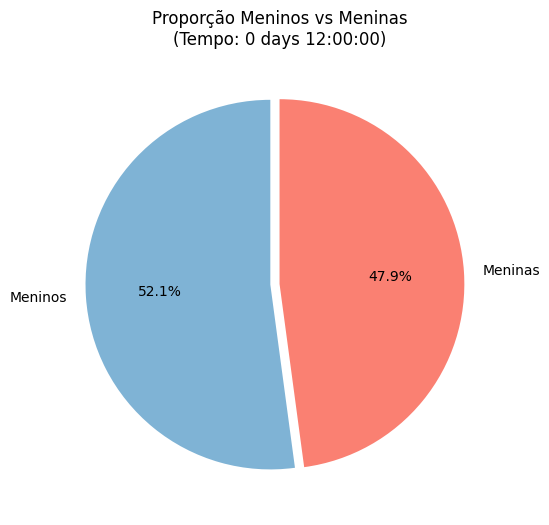

************************************************************************************************************************


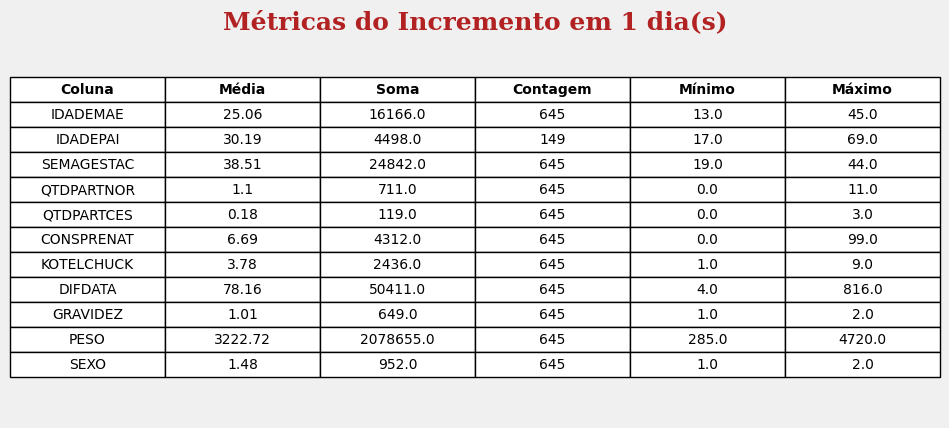

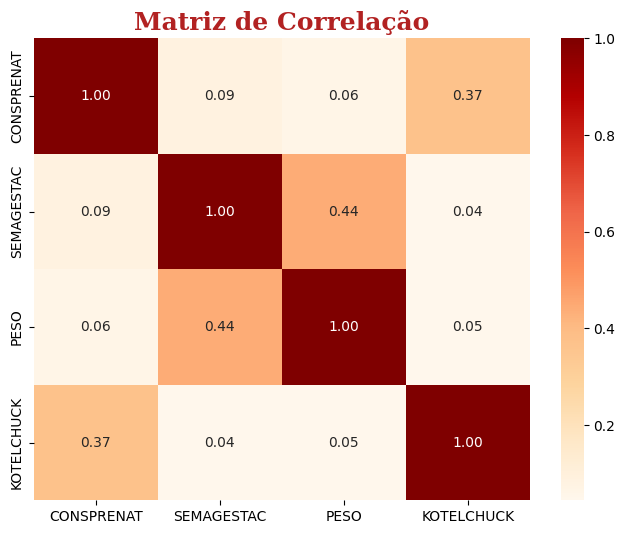

Número de classes (Sturges): 10


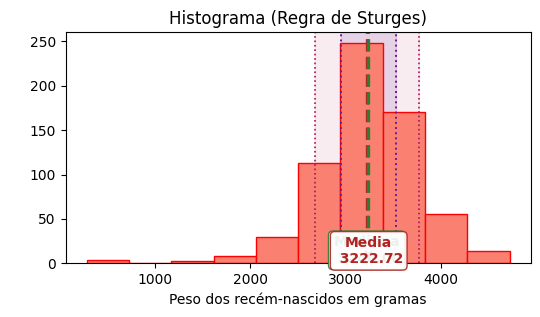

Distância Média/Mediana: -17.28
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



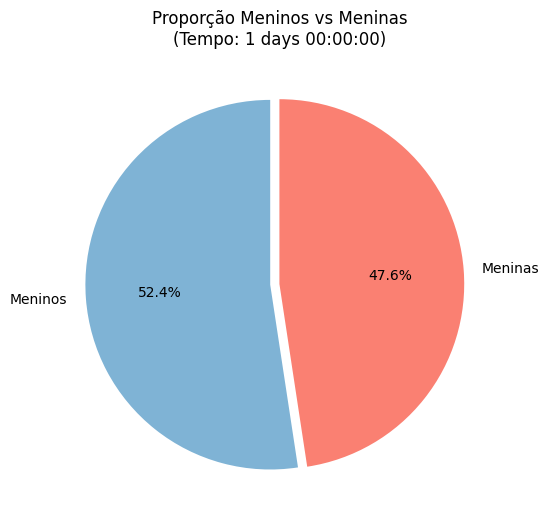

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.53s
**************************************************

Memória inicial: 4007.22 MB
Memória final: 4013.52 MB
Memória total utilizada no processo: 6.30 MB
**************************************************



In [31]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = pc.min(tabela_final['DTNASC']).as_py()
condicao = pc.less_equal(tabela_final['DATA_HORA_NASC'], data_inicio)

for tempo in intervalos_iniciais:
    data_limite = data_inicio + tempo
    df_incremento = tabela_final.filter(pc.field('DATA_HORA_NASC') <= data_limite)
    info = metricas(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pyarrow",
        "Ação" : "Operações e gráficos: 12h a 1 dia",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

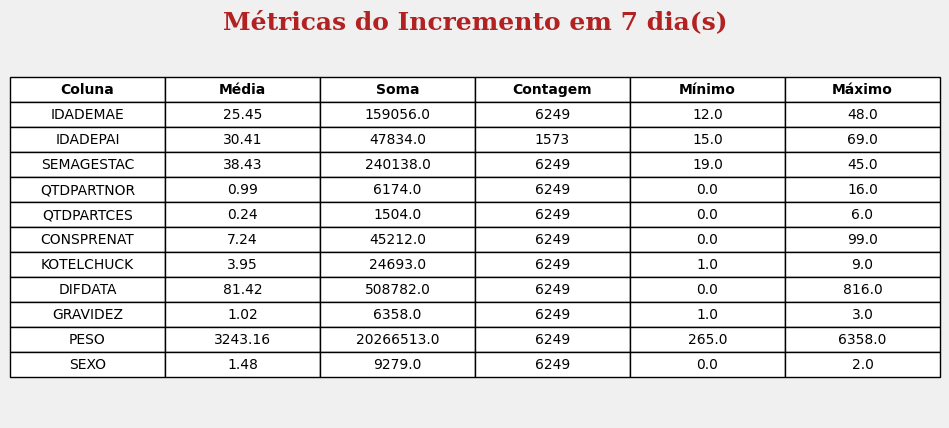

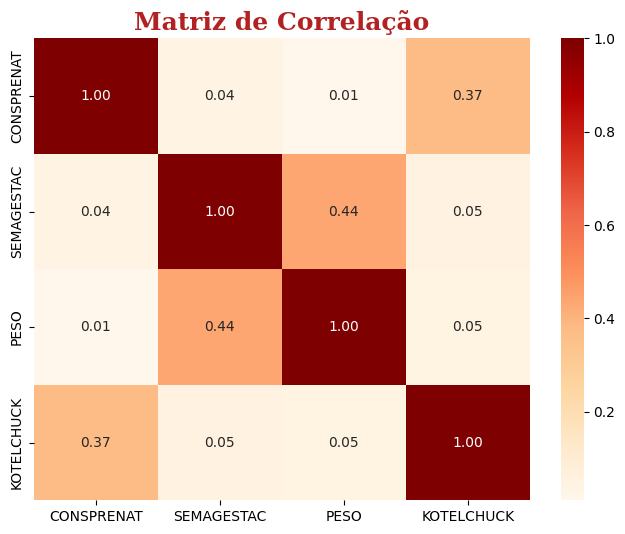

Número de classes (Sturges): 13


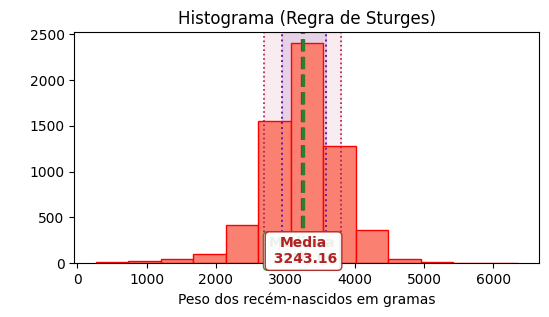

Distância Média/Mediana: -11.84
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



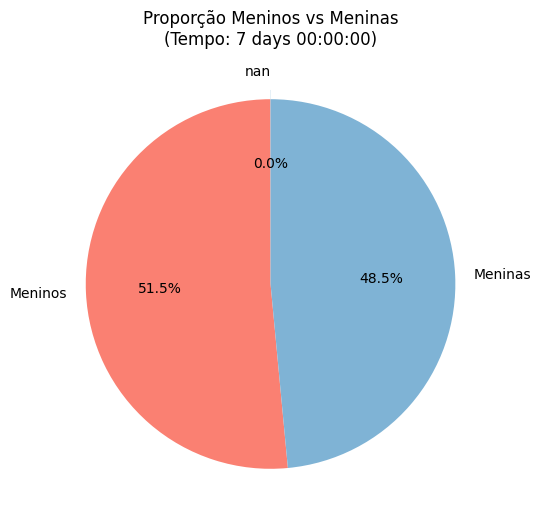

************************************************************************************************************************


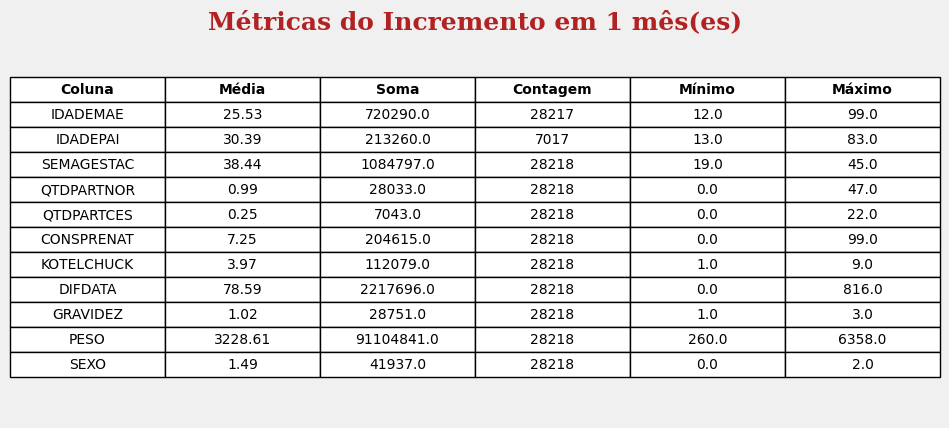

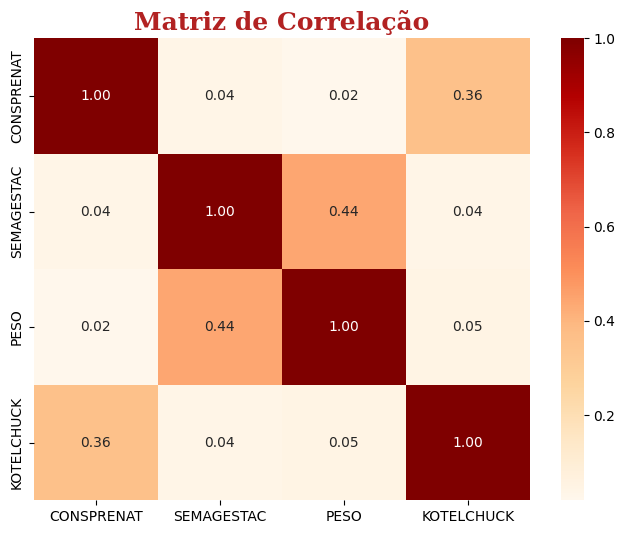

Número de classes (Sturges): 15


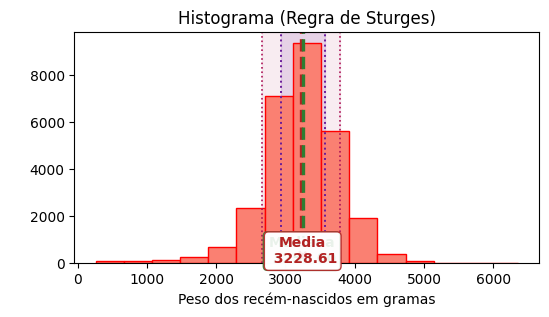

Distância Média/Mediana: -21.39
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



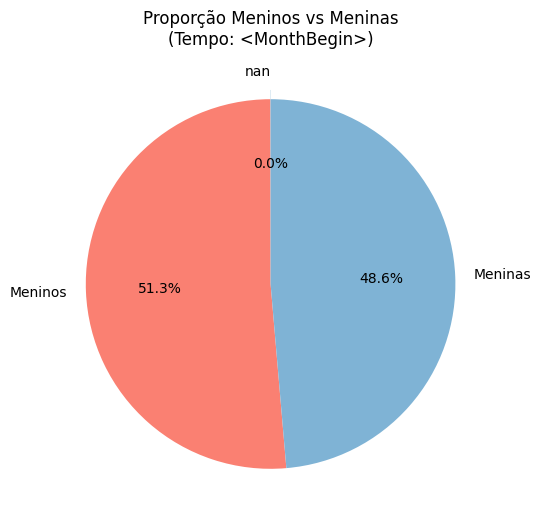

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.60s
**************************************************

Memória inicial: 4013.52 MB
Memória final: 4017.27 MB
Memória total utilizada no processo: 3.75 MB
**************************************************



In [32]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = pc.min(tabela_final['DTNASC']).as_py()
condicao = pc.less_equal(tabela_final['DATA_HORA_NASC'], data_inicio)

for tempo in intervalos_medianos:
    data_limite = data_inicio + tempo
    df_incremento = tabela_final.filter(pc.field('DATA_HORA_NASC') <= data_limite)
    info = metricas(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pyarrow",
        "Ação" : "Operações e gráficos: 1 semana a 1 mes",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_inicio - memoria_fim)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_inicio - memoria_fim):.2f} MB")
print(f'{"*"*50}\n')

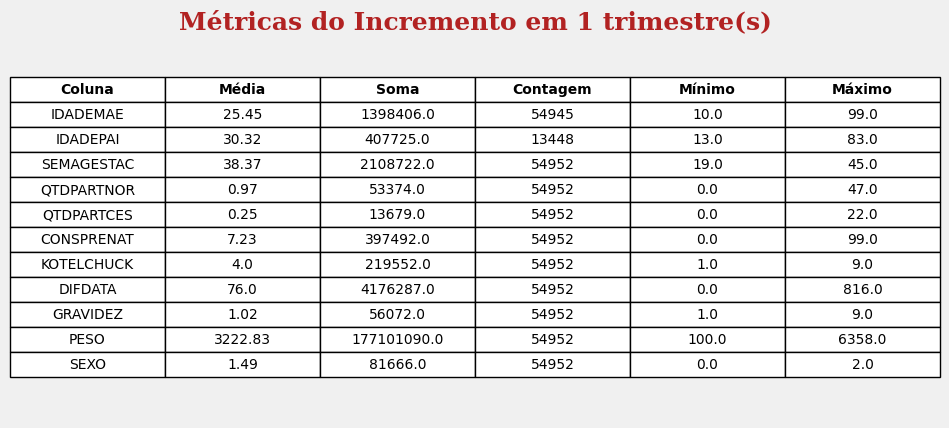

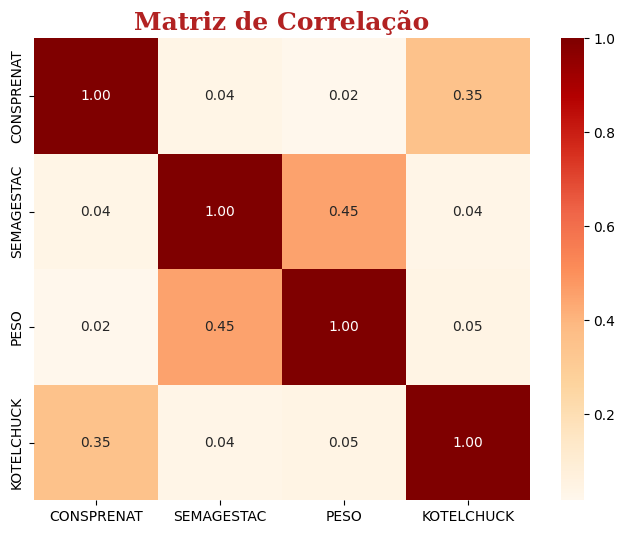

Número de classes (Sturges): 16


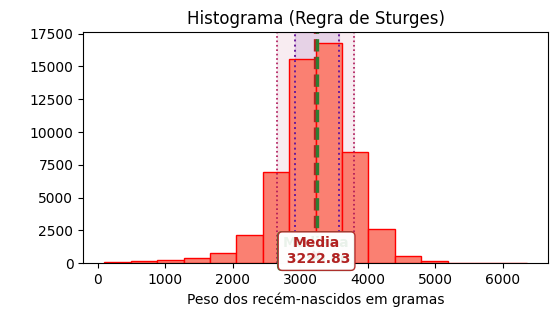

Distância Média/Mediana: -27.17
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



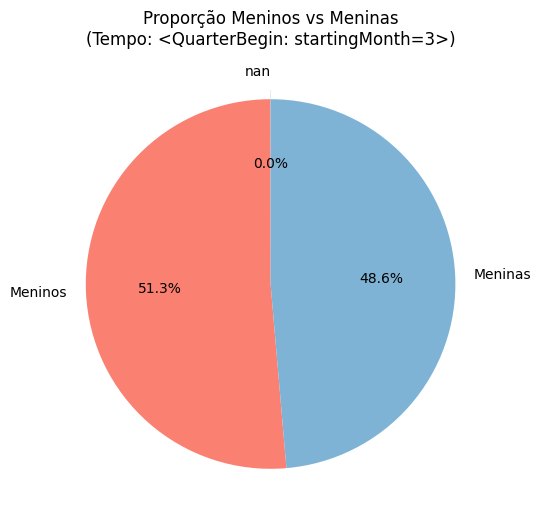

************************************************************************************************************************


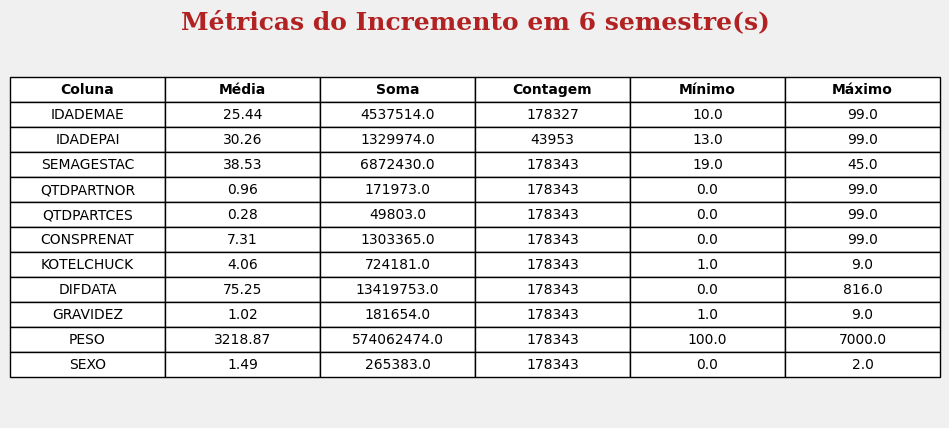

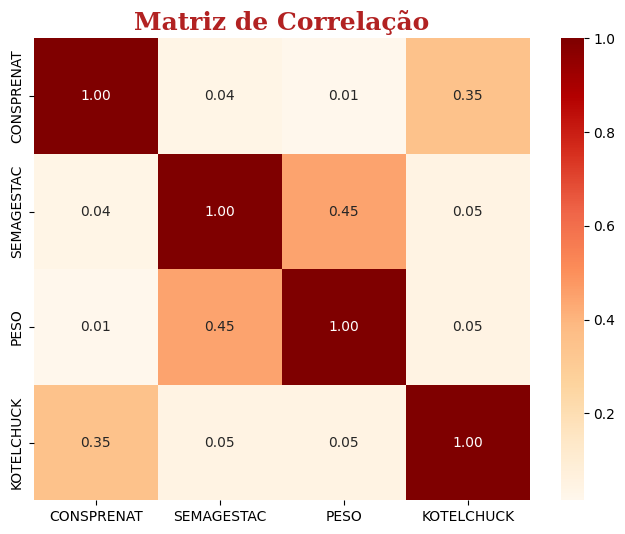

Número de classes (Sturges): 18


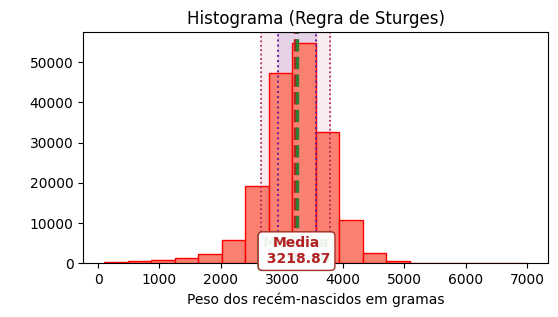

Distância Média/Mediana: -31.13
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



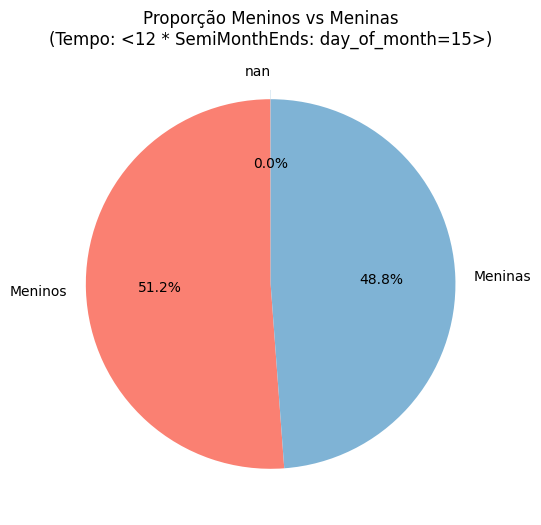

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.54s
**************************************************

Memória inicial: 4017.27 MB
Memória final: 4024.08 MB
Memória total utilizada no processo: 6.80 MB
**************************************************



In [33]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = pc.min(tabela_final['DTNASC']).as_py()
condicao = pc.less_equal(tabela_final['DATA_HORA_NASC'], data_inicio)

for tempo in intervalos_finais:
    data_limite = data_inicio + tempo
    df_incremento = tabela_final.filter(pc.field('DATA_HORA_NASC') <= data_limite)
    info = metricas(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pyarrow",
        "Ação" : "Operações e gráficos: 3 meses a 6 meses",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_inicio - memoria_fim):.2f} MB")
print(f'{"*"*50}\n')

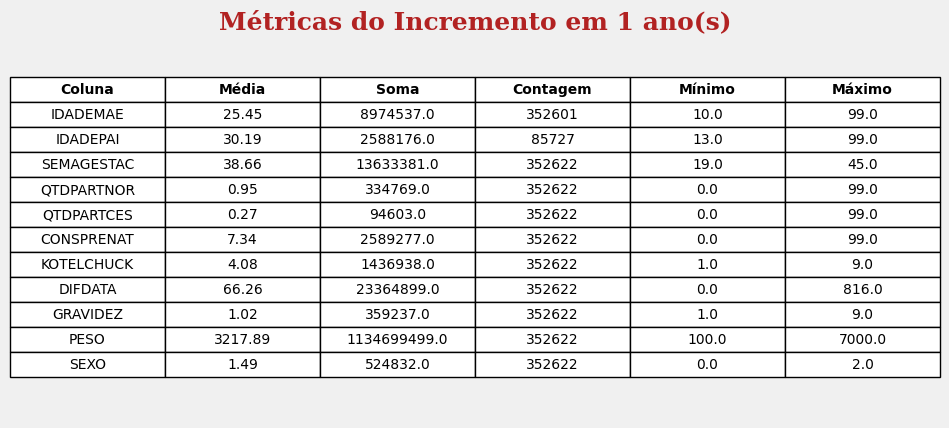

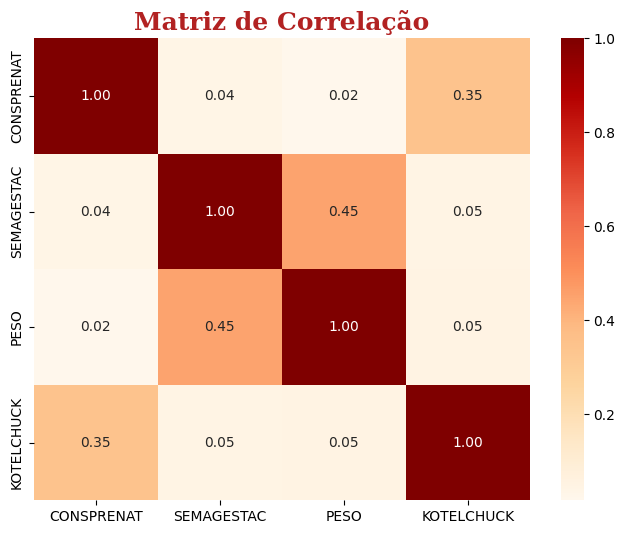

Número de classes (Sturges): 19


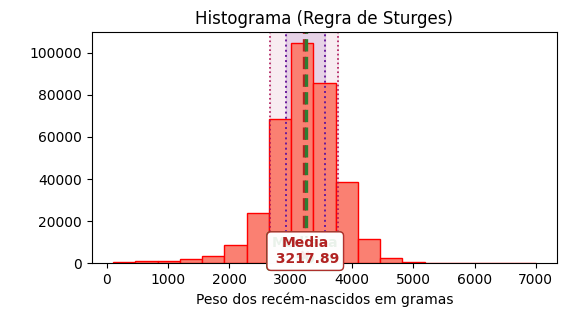

Distância Média/Mediana: -32.11
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



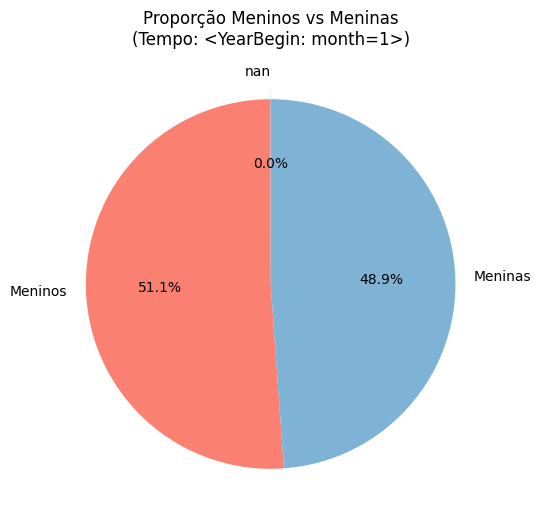

************************************************************************************************************************


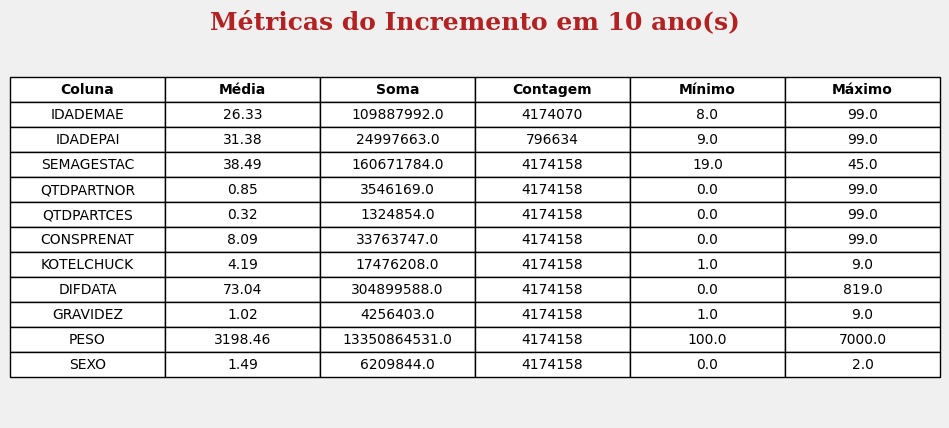

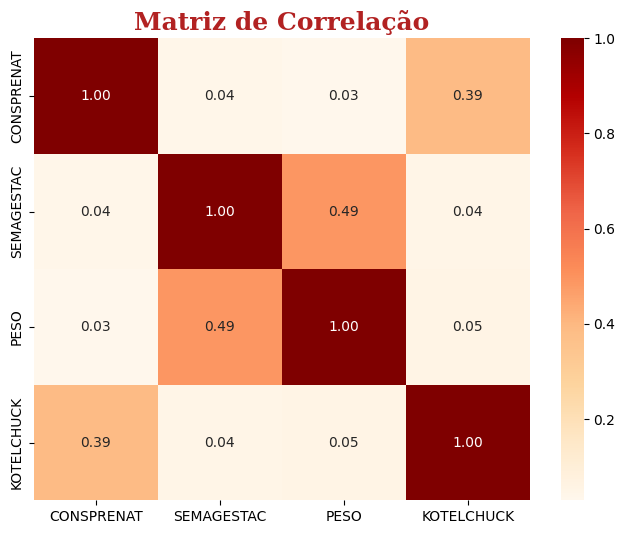

Número de classes (Sturges): 22


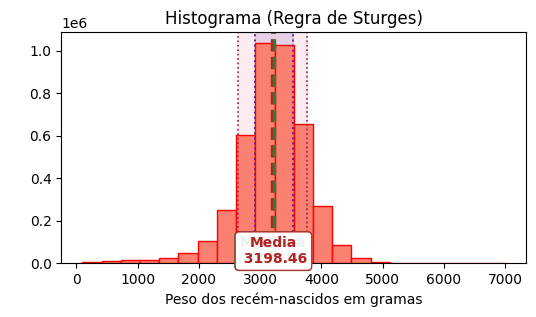

Distância Média/Mediana: -31.54
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



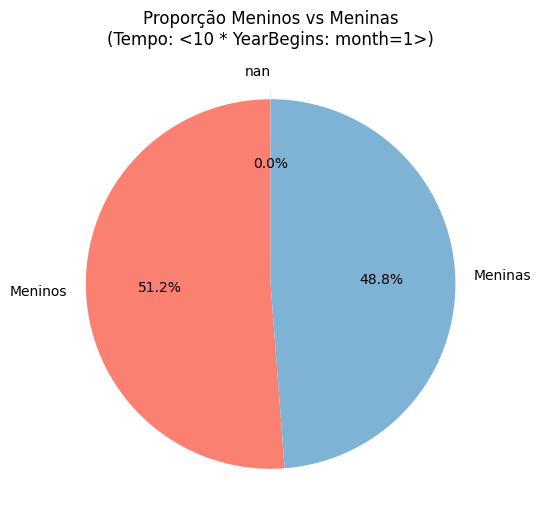

************************************************************************************************************************
**************************************************

Tempo total de processamento: 3.09s
**************************************************

Memória inicial: 4024.08 MB
Memória final: 4408.95 MB
Memória total utilizada no processo: 384.87 MB
**************************************************



In [34]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = pc.min(tabela_final['DTNASC']).as_py()
condicao = pc.less_equal(tabela_final['DATA_HORA_NASC'], data_inicio)

for tempo in intervalos_alemDoFim:
    data_limite = data_inicio + tempo
    df_incremento = tabela_final.filter(pc.field('DATA_HORA_NASC') <= data_limite)
    info = metricas(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Pyarrow",
        "Ação" : "Operações e gráficos: 1 ano a 10 anos(limite)",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_inicio - memoria_fim)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_inicio - memoria_fim):.2f} MB")
print(f'{"*"*50}\n')

> polars

In [35]:
def metricas_polars(df_incremento, tempo):
    df_numerico = df_incremento.select(cs.integer() | cs.float())
    
    if df_numerico.width == 0:
        print("Nenhuma coluna numérica encontrada.")
        return []

    res_mean = df_numerico.select(pl.all().mean().round(2))
    res_sum  = df_numerico.select(pl.all().sum())
    res_cnt  = df_numerico.select(pl.all().count())
    res_min  = df_numerico.select(pl.all().min())
    res_max  = df_numerico.select(pl.all().max())

    colunas = df_numerico.columns
    lista_stats = []

    for col in colunas:
        stats_linha = {
            "Coluna": col,
            "Média": res_mean[col][0] if res_mean[col][0] is not None else 0,
            "Soma": res_sum[col][0],
            "Contagem": res_cnt[col][0],
            "Mínimo": res_min[col][0],
            "Máximo": res_max[col][0]
        }
        lista_stats.append(stats_linha)
    
    df_plot = pd.DataFrame(lista_stats)
    
    altura = max(2, len(df_plot) * 0.45)
    fig, ax = plt.subplots(figsize=(10, altura), facecolor='#f0f0f0') 
    ax.axis('off')
    
    tabela = ax.table(
        cellText=df_plot.values, 
        colLabels=df_plot.columns, 
        loc='center', 
        cellLoc='center'
    )
    
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.5) 
    
    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            
    tempo_formatado = formatar_tempo(tempo)
    plt.title(f"Métricas do Incremento em {tempo_formatado}", fontdict=estilo_titulo)
    plt.show()
    
    return lista_stats

2024-01-01 00:00:00


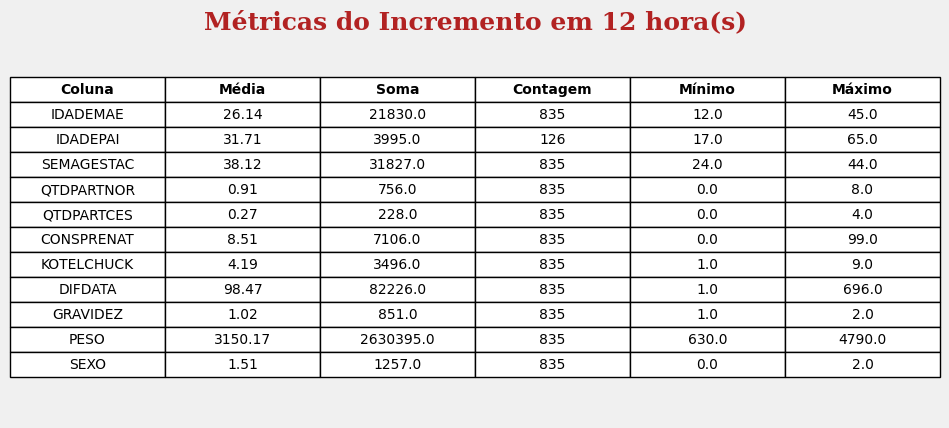

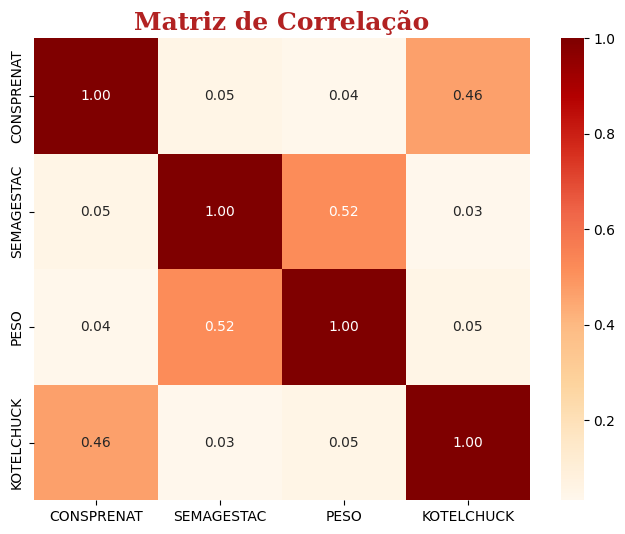

Número de classes (Sturges): 10


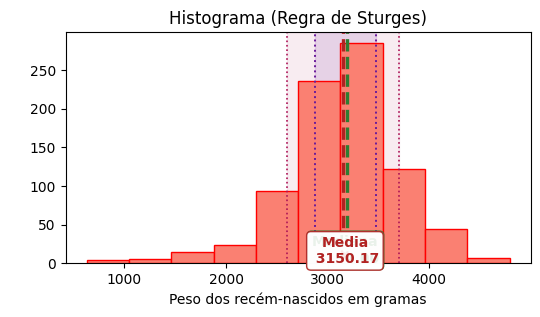

Distância Média/Mediana: -43.83
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



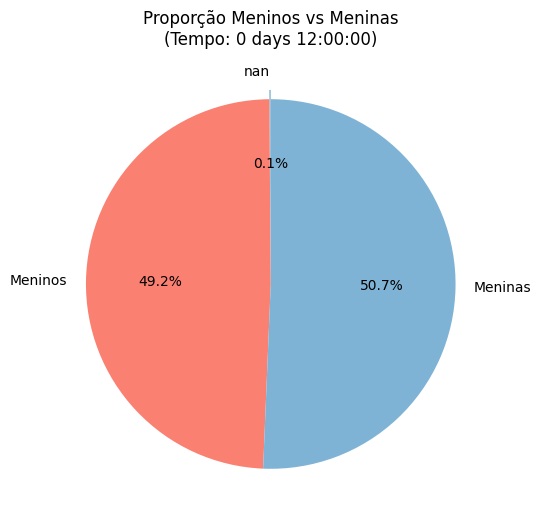

************************************************************************************************************************


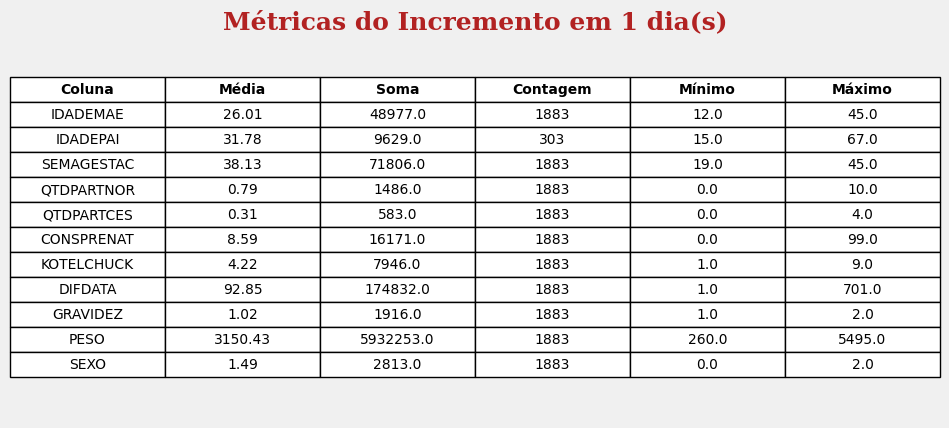

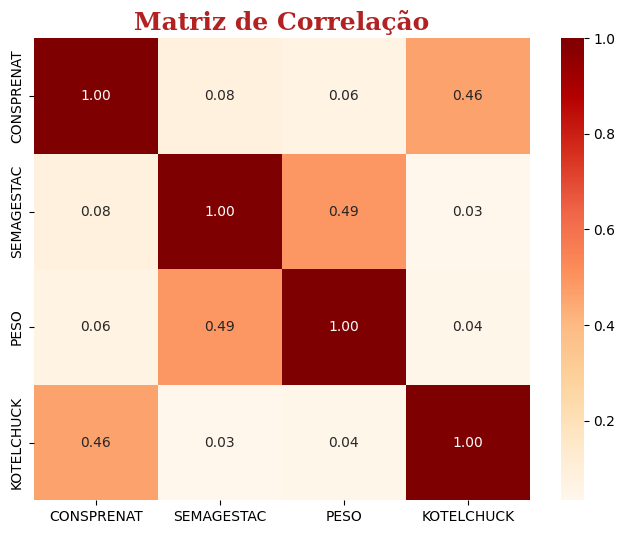

Número de classes (Sturges): 11


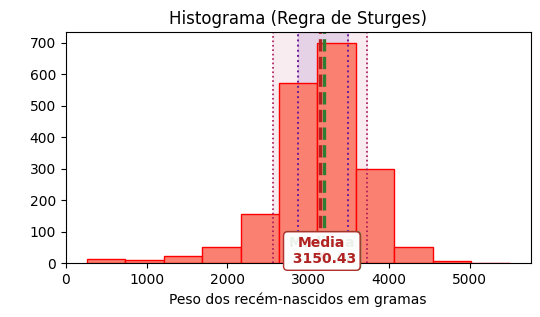

Distância Média/Mediana: -44.57
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



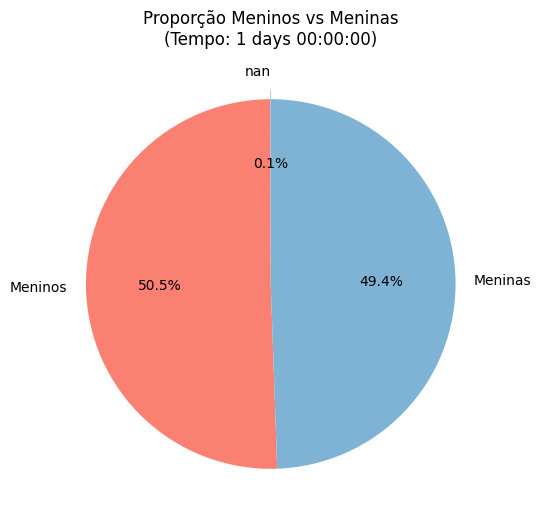

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.38s
**************************************************

Memória inicial: 4408.95 MB
Memória final: 4148.28 MB
Memória total utilizada no processo: 260.67 MB
**************************************************



In [36]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

pl_lotes_validados = []
data_inicio = df_polars_novo["DTNASC"].min()
print(data_inicio)
for tempo in intervalos_iniciais:
    data_limite = data_inicio + tempo
    df_incremento = df_polars_novo.filter(
        pl.col('DATA_HORA_NASC') <= data_limite
    )
    
    info = metricas_polars(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Polars",
        "Ação" : "Operações e gráficos: 12h a 1 dia",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

2024-01-01 00:00:00


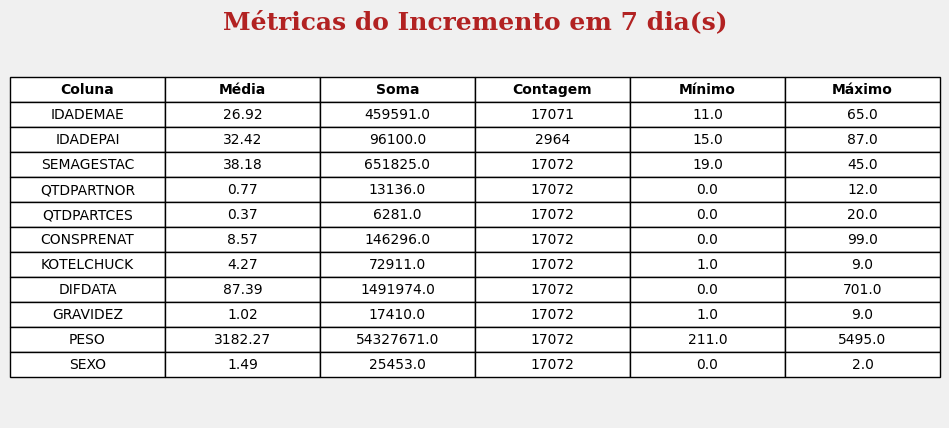

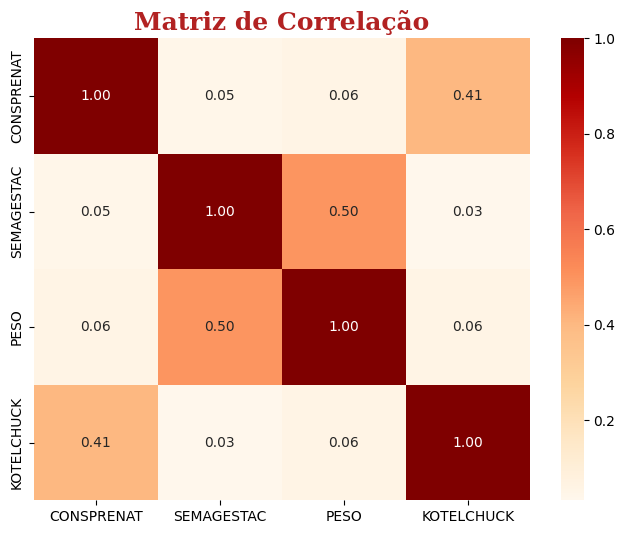

Número de classes (Sturges): 15


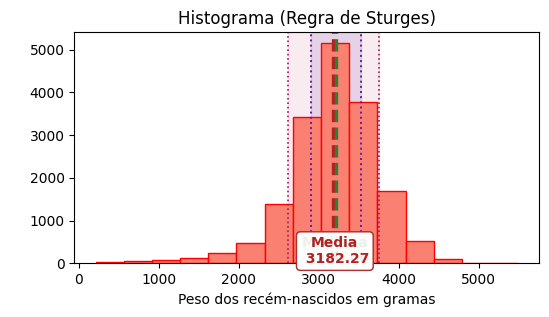

Distância Média/Mediana: -37.73
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



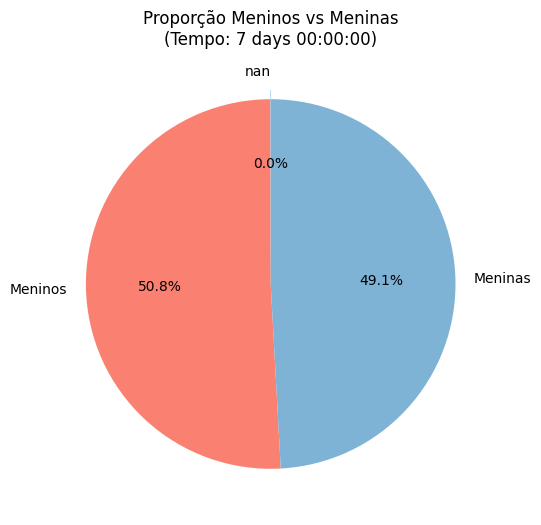

************************************************************************************************************************


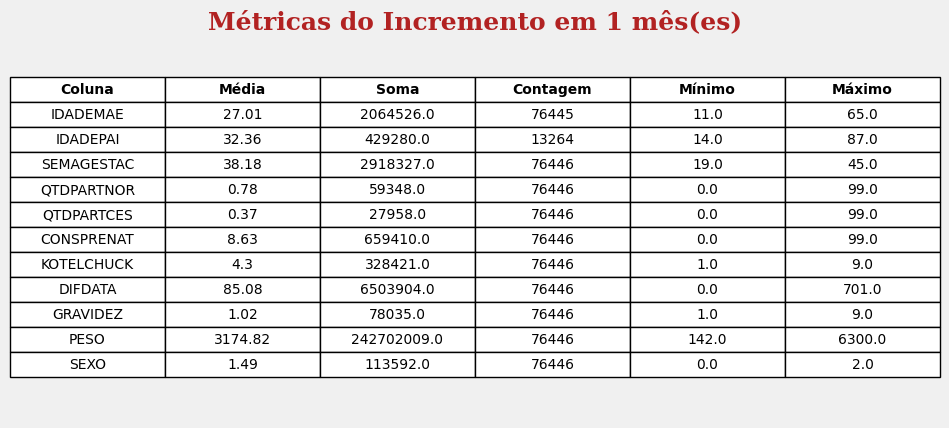

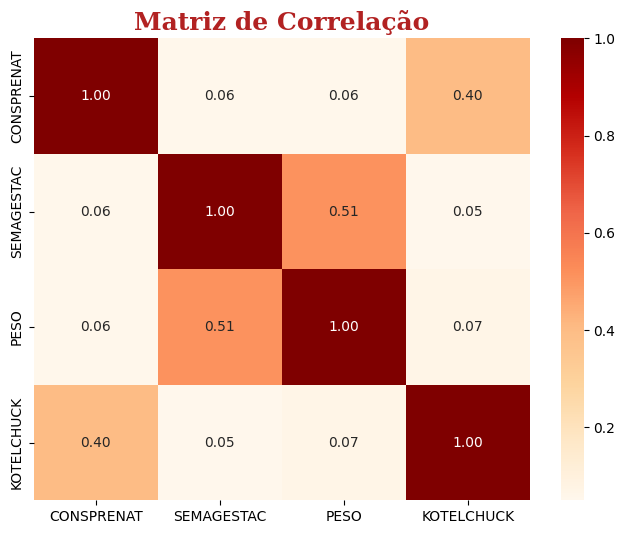

Número de classes (Sturges): 17


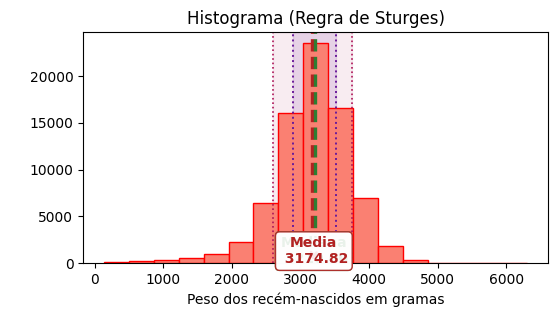

Distância Média/Mediana: -35.18
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



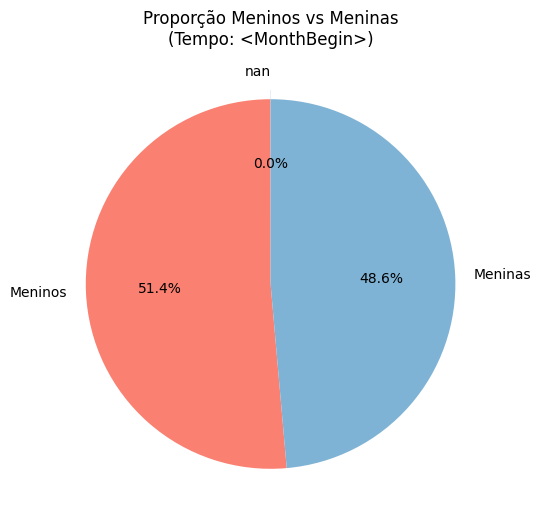

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.55s
**************************************************

Memória inicial: 4148.28 MB
Memória final: 3905.79 MB
Memória total utilizada no processo: 242.49 MB
**************************************************



In [37]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

pl_lotes_validados = []
data_inicio = df_polars_novo["DTNASC"].min()
print(data_inicio)
for tempo in intervalos_medianos:
    data_limite = data_inicio + tempo
    df_incremento = df_polars_novo.filter(
        pl.col('DATA_HORA_NASC') <= data_limite
    )
    
    info = metricas_polars(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Polars",
        "Ação" : "Operações e gráficos: 1 semana a 1 mes",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

2024-01-01 00:00:00


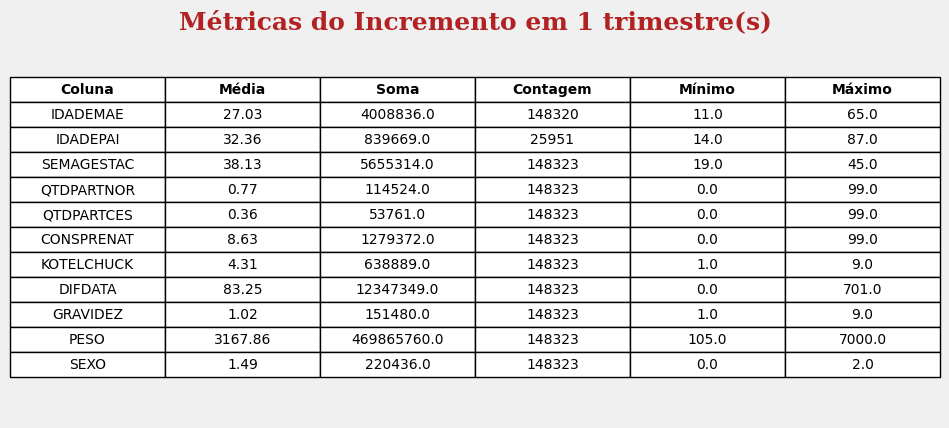

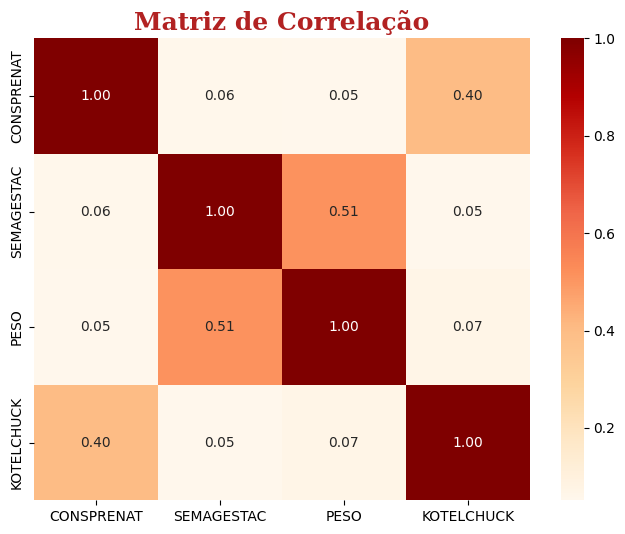

Número de classes (Sturges): 18


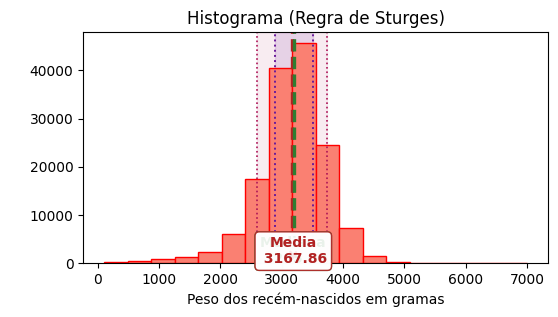

Distância Média/Mediana: -37.14
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



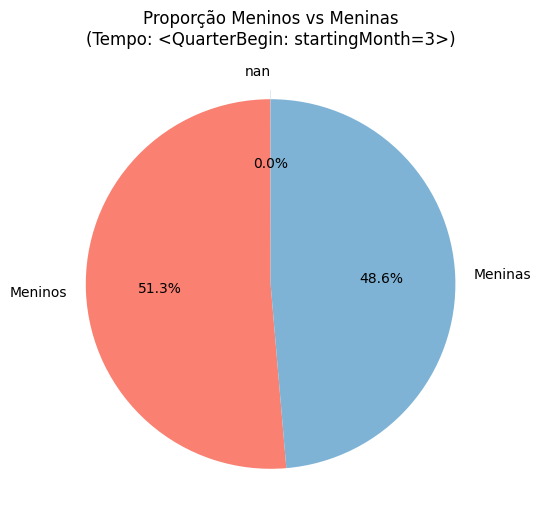

************************************************************************************************************************


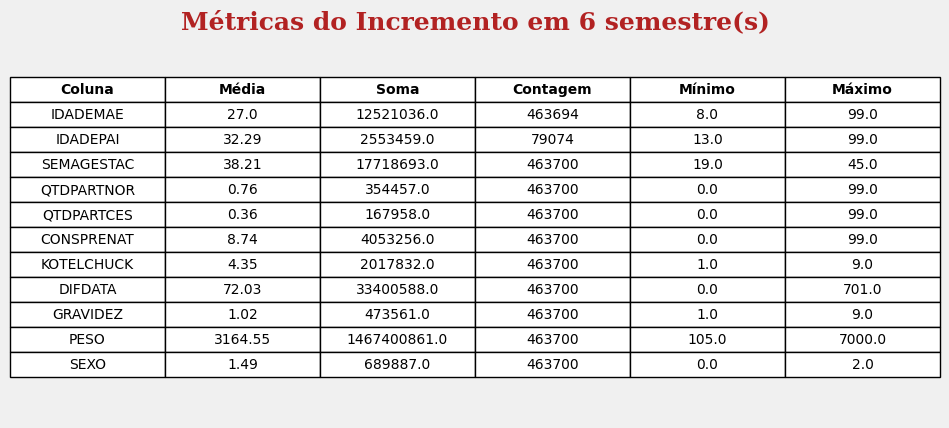

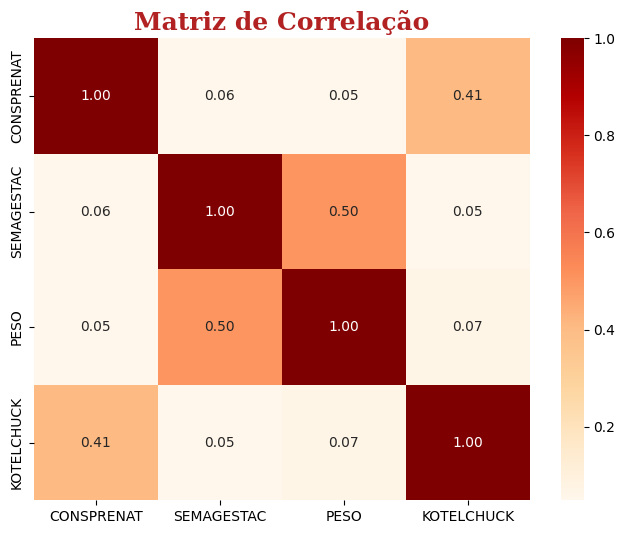

Número de classes (Sturges): 19


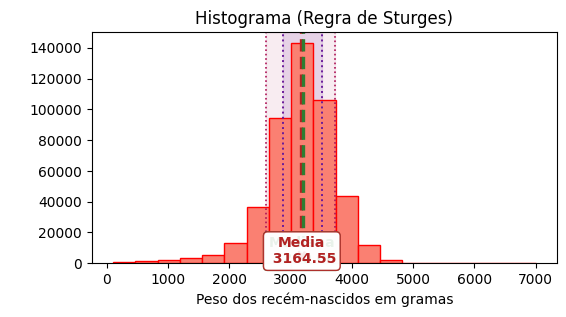

Distância Média/Mediana: -35.45
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



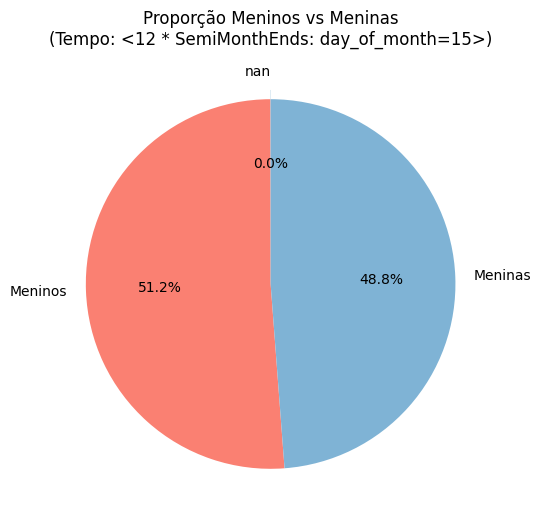

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.55s
**************************************************

Memória inicial: 3905.79 MB
Memória final: 3953.68 MB
Memória total utilizada no processo: 47.90 MB
**************************************************



In [38]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

pl_lotes_validados = []
data_inicio = df_polars_novo["DTNASC"].min()
print(data_inicio)
for tempo in intervalos_finais:
    data_limite = data_inicio + tempo
    df_incremento = df_polars_novo.filter(
        pl.col('DATA_HORA_NASC') <= data_limite
    )
    
    info = metricas_polars(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Polars",
        "Ação" : "Operações e gráficos: 3 meses a 6 meses",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

2024-01-01 00:00:00


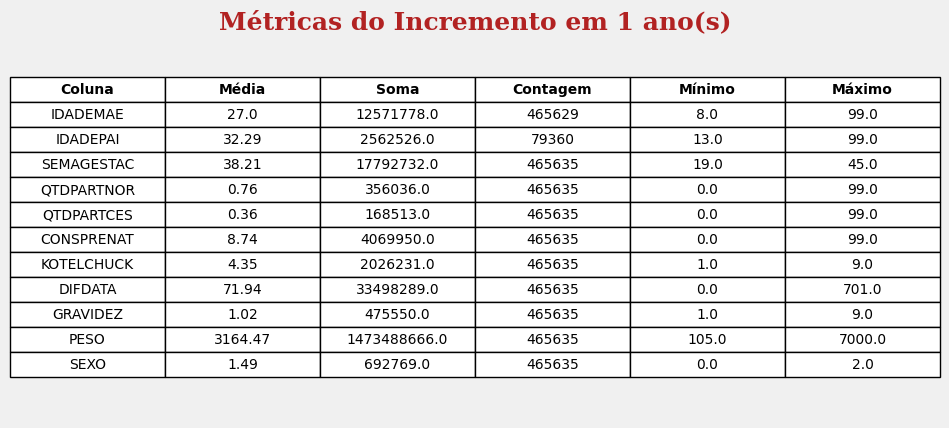

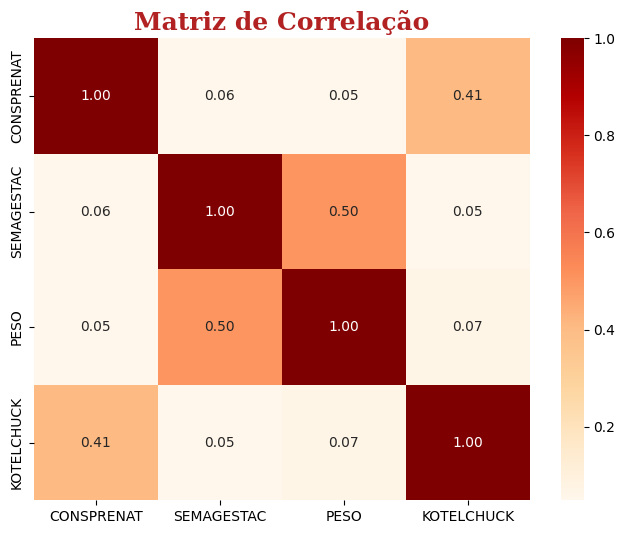

Número de classes (Sturges): 19


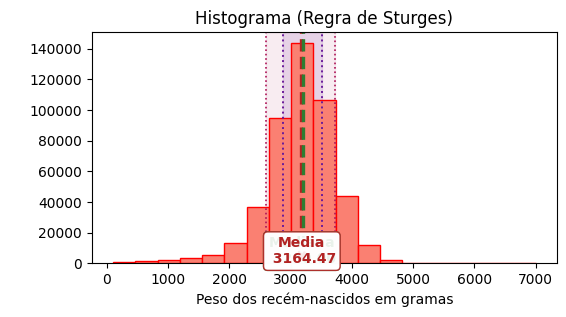

Distância Média/Mediana: -35.53
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



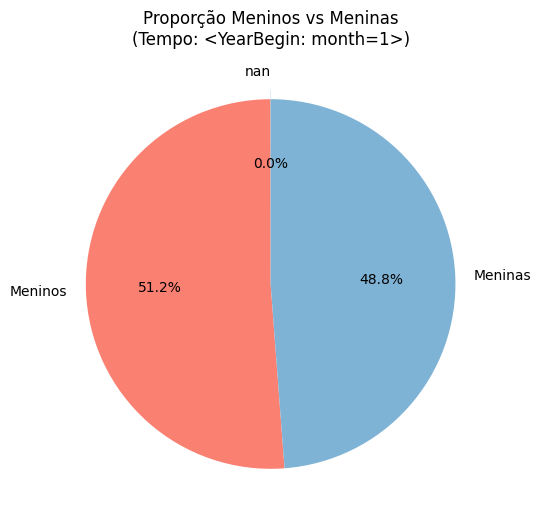

************************************************************************************************************************


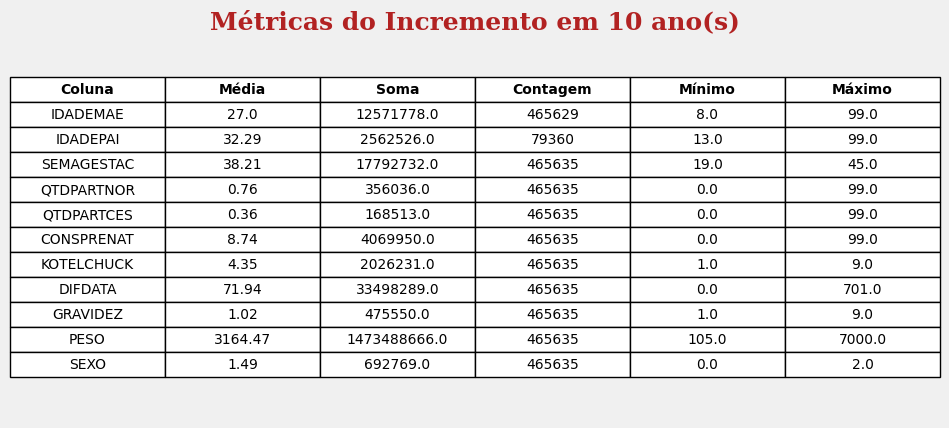

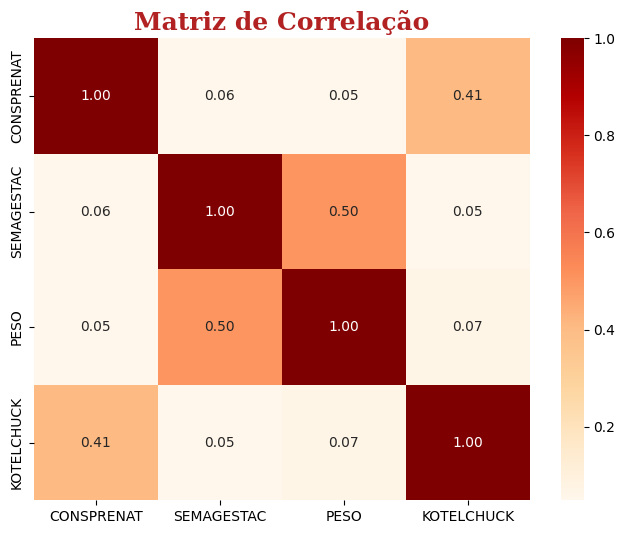

Número de classes (Sturges): 19


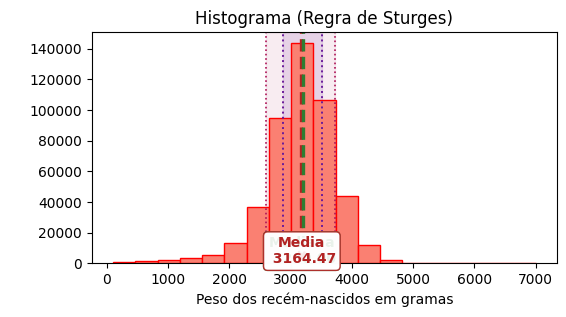

Distância Média/Mediana: -35.53
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



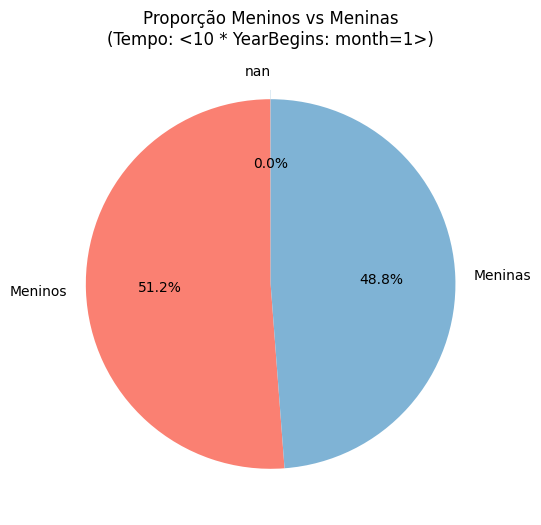

************************************************************************************************************************
**************************************************

Tempo total de processamento: 1.65s
**************************************************

Memória inicial: 3953.68 MB
Memória final: 3954.41 MB
Memória total utilizada no processo: 0.72 MB
**************************************************



In [39]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

pl_lotes_validados = []
data_inicio = df_polars_novo["DTNASC"].min()
print(data_inicio)
for tempo in intervalos_alemDoFim:
    data_limite = data_inicio + tempo
    df_incremento = df_polars_novo.filter(
        pl.col('DATA_HORA_NASC') <= data_limite
    )
    
    info = metricas_polars(df_incremento, tempo)
    grafico_de_correlacao(df_incremento, tempo)
    grafico_de_sturges(df_incremento, tempo)
    grafico_de_pizza(df_incremento, tempo)
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo = fim - inicio

memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append(
    {
        "Biblioteca" : "Polars",
        "Ação" : "Operações e gráficos: 1 ano a 10 anos(limite)",
        "Tempo" : tempo,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    }
)

print(f'{"*"*50}\n')
if(tempo<60):
    print(f'Tempo total de processamento: {tempo:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

> Dask

In [40]:
def metricas_dask(df_incremento, tempo):
    df_numerico = df_incremento.select_dtypes(include=[np.number])
    
    if len(df_numerico.columns) == 0:
        print("Nenhuma coluna numérica encontrada.")
        return []
    stats = df_numerico.compute().agg(['mean', 'sum', 'count', 'min', 'max'])
    
    # Colunas viram linhas
    stats_t = stats.T.reset_index()
    stats_t.columns = ['Coluna', 'Média', 'Soma', 'Contagem', 'Mínimo', 'Máximo']
    
    # Arredonda a média
    stats_t['Média'] = stats_t['Média'].round(2).fillna(0)

    # Converte para a lista de dicionários (mantendo sua estrutura de retorno)
    lista_stats = stats_t.to_dict('records')
    
    # Preparação do Plot (quase idêntico ao original, usando o df gerado pelo pandas)
    df_plot = stats_t
    
    altura = max(2, len(df_plot) * 0.45)
    fig, ax = plt.subplots(figsize=(10, altura), facecolor='#f0f0f0') 
    ax.axis('off')
    
    tabela = ax.table(
        cellText=df_plot.values, 
        colLabels=df_plot.columns, 
        loc='center', 
        cellLoc='center'
    )
    
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.5) 
    
    # Estilização do cabeçalho
    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            
    tempo_formatado = formatar_tempo(tempo)
    plt.title(f"Métricas do Incremento em {tempo_formatado}", fontdict=estilo_titulo)
    plt.show()
    
    return lista_stats

In [41]:
def grafico_de_correlacao_dask(df_incremento, tempo):
    
    colunas_selecionadas = ['CONSPRENAT', 'SEMAGESTAC', 'PESO', 'KOTELCHUCK'] 
    corr = df_incremento[colunas_selecionadas].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='OrRd', fmt=".2f")
    
    plt.title('Matriz de Correlação', fontdict = estilo_titulo)
    plt.show()

In [42]:
def grafico_de_sturges_dask(df_incremento, tempo):
    
    serie = df_incremento['PESO'] 
    
    fig, ax   = plt.subplots(figsize =(6, 3))
    
    media   = serie.mean() # media
    mediana = serie.median() # mediana
    dp      = serie.std() # Mede a dispersão; quanto os dados variam em relação à média.
    q1      = serie.quantile(0.25) 
    q3      = serie.quantile(0.75)
    p99     = serie.quantile(0.99) # Valor que delimita os 1% maiores dados da série.
    skew    = serie.skew() # Mede a falta de simetria da distribuição.

    
    series_vis = serie[serie<= p99]
    n_fora    = (serie > p99).sum()

    media = media.compute()
    mediana = mediana.compute()
    dp = dp.compute()
    q1 = q1.compute()
    q3 = q3.compute()
    p99 = p99.compute()
    skew = skew.compute()
    
    #desvio padrão
    #avxspan - Define uma área de sombreamento
    # 1° linha: define o tamanho do sombreamento. (0, media-dp), onde começa e media + dp, one termina.
    # 2° linha: define a transparência da área.
    ax.axvspan(
        max(0, media - dp),
        media + dp,
        alpha=0.08,
        color=COR_DESVIO,
        label=f'Media desv (desv = {dp:.2f})'
    )
    ax.axvline(max(0, media - dp), color=COR_DESVIO, lw=1.2, ls=':') # define a linha de demarcação
    ax.axvline( (media + dp), color=COR_DESVIO, lw=1.2, ls=':') # define a linha de demarcação

    #IQR
    ax.axvspan(
        q1, q3,
        alpha=0.12,
        color=COR_IQR,
        label=f'IQR: Q1 = {q1:.2f} - Q3 = {q3:.2f}'
    )
    
    ax.axvline(q1, color=COR_IQR, lw=1.4, ls=':')
    ax.axvline(q3, color=COR_IQR, lw=1.4, ls=':')
    
    #Medidas de localização
    ax.axvline(media, color =  'firebrick', lw = 2.4, ls="--", label=f'Média = {media:.2f}')
    ax.axvline(mediana, color =  COR_MEDIANA, lw = 2.4, ls="--", label=f'Mediana = {mediana:.2f}')

    
    ymax = ax.get_ylim()[1]
    
    #Mediana linha
    ax.annotate(f'Mediana\n {mediana:.2f}',
               xy=(mediana, ymax *0.72),
               xytext = (mediana - 18, ymax *0.92),
               color = COR_MEDIANA, fontsize =10, fontweight ='bold',
               ha = 'center',
               arrowprops = dict(arrowstyle = '->', color = COR_MEDIANA, lw=1.8),
               bbox = dict(boxstyle = 'round, pad=0.3', facecolor = 'white',
                                 edgecolor= COR_MEDIANA, alpha = 0.9),
    )

    #media linha
    ax.annotate(f'Media\n {media:.2f}',
               xy=(media, ymax *0.60),
               xytext = (media + 20, ymax *0.30),
               color = 'firebrick', fontsize =10, fontweight ='bold',
               ha = 'center',
               arrowprops = dict(arrowstyle = '->', color = 'firebrick', lw=1.8),
               bbox = dict(boxstyle = 'round, pad=0.3', facecolor = 'white',
                                 edgecolor= 'firebrick', alpha = 0.9),
    )
    
    # Fórmula de "sturges"
    n = len(serie)
    k = int(1 + 3.322 * np.log10(n))
    
    print(f"Número de classes (Sturges): {k}")
    
    # Histograma
    plt.hist(df_incremento['PESO'] , bins=k, color = 'salmon', edgecolor='red')
    plt.title(f"Histograma (Regra de Sturges)")
    plt.xlabel("Peso dos recém-nascidos em gramas")
    plt.ylabel(" ")
    plt.show()

    
    distancia = (serie.mean() - serie.median())
    assimetria = ''

    
    distancia = distancia.compute()
    if (distancia > 0):
        assimetria = 'Assimetria à direita - POSITIVA!'
    elif(distancia < 0):
        assimetria = 'Assimetria à esquerda - NEGATIVA!'
    else:
        assimetria = 'Simétrica'
    
    print(f"Distância Média/Mediana: {distancia:.2f}\n"
          f'{assimetria}\n'
          f'{'_'*120}\n'
         )

In [43]:
def grafico_de_pizza_dask(df_incremento, tempo):
    
    contagem = df_incremento.groupby('SEXO').size()
    contagem = contagem.compute()
    contagem.index = contagem.index.map({1: 'Meninos', 2: 'Meninas'})
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    cores = ['#7FB3D5', 'salmon']

    ax.pie(contagem, 
           labels=contagem.index, 
           autopct='%1.1f%%', 
           startangle=90, 
           colors=cores,
           explode = [0.05] + [0]*(len(contagem)-1))
    tempo_formatado = formatar_tempo(tempo)
    ax.set_title(f"Proporção Meninos vs Meninas\n(Tempo: {tempo_formatado})")
    
    plt.show()

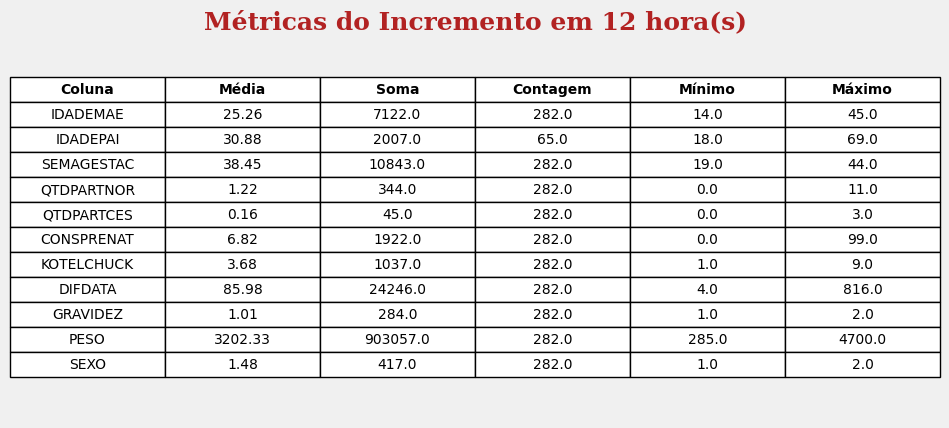

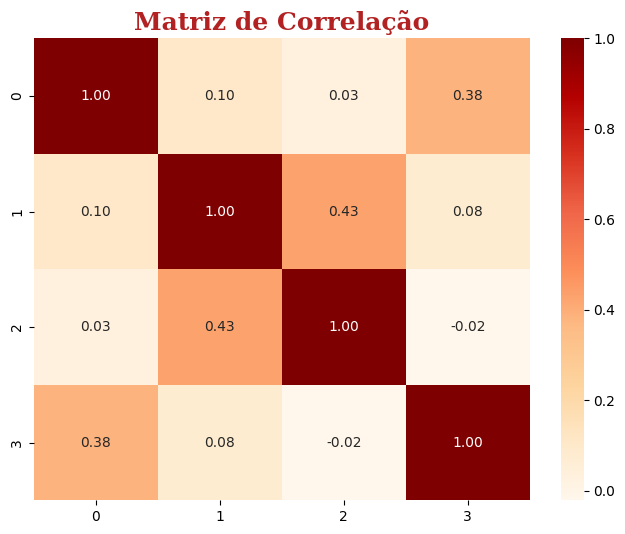

Número de classes (Sturges): 9


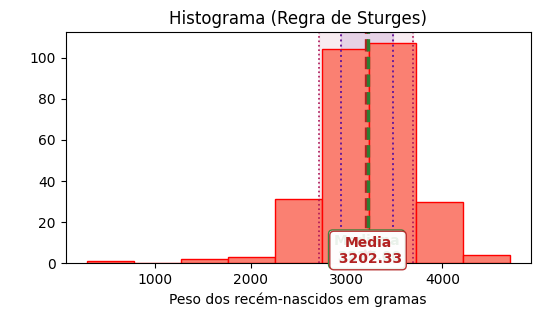

Distância Média/Mediana: -24.67
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



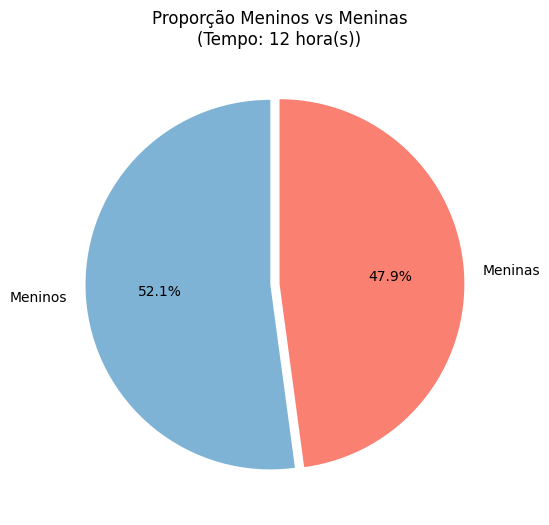

************************************************************************************************************************


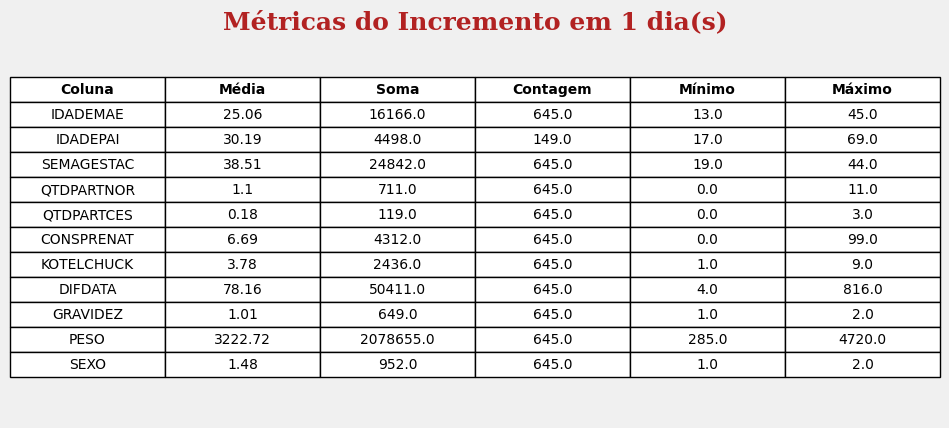

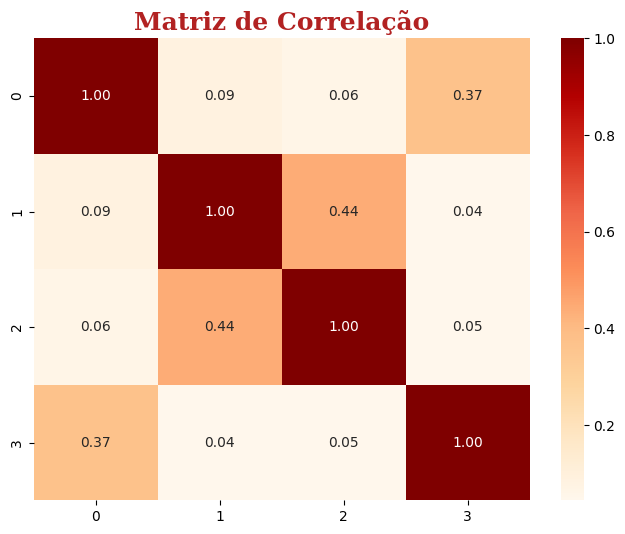

Número de classes (Sturges): 10


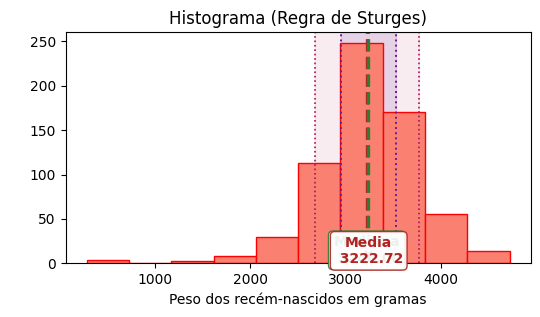

Distância Média/Mediana: -17.28
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



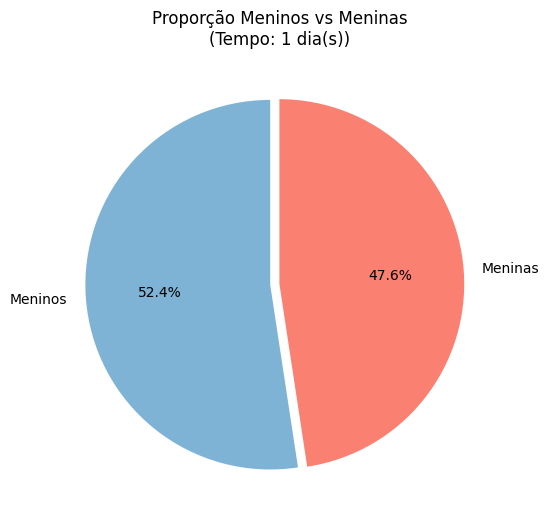

************************************************************************************************************************
**************************************************

Tempo total de processamento: 6.97 min
**************************************************

Memória inicial: 3954.43 MB
Memória final: 4464.75 MB
Memória total utilizada no processo: 510.32 MB
**************************************************



In [44]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = ddf_limpo["DTNASC"].min().compute() 

for tempo in intervalos_iniciais:
    data_limite = data_inicio + tempo
    
    df_incremento = ddf_limpo[ddf_limpo['DATA_HORA_NASC'] <= data_limite]
    
    info = metricas_dask(df_incremento, tempo) 
    grafico_de_correlacao_dask(df_incremento, tempo) # Exemplo de nome
    grafico_de_sturges_dask(df_incremento, tempo)    # Exemplo de nome
    grafico_de_pizza_dask(df_incremento, tempo)      # Exemplo de nome
    
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo_total = fim - inicio
memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append({
    "Biblioteca" : "Dask",
    "Ação" : "Operações e gráficos: 12h a 1 dia",
    "Tempo" : tempo_total,
    "Memória Utilizada": abs(memoria_fim - memoria_inicio)
})

print(f'{"*"*50}\n')
if(tempo_total < 60):
    print(f'Tempo total de processamento: {tempo_total:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo_total/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

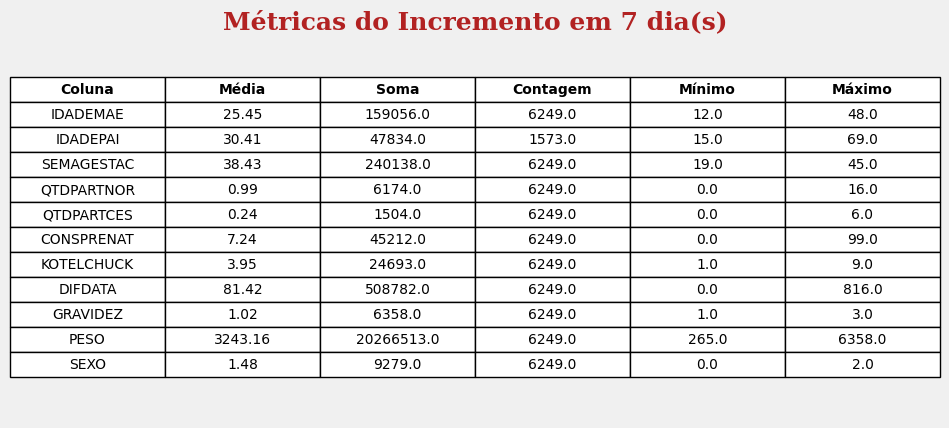

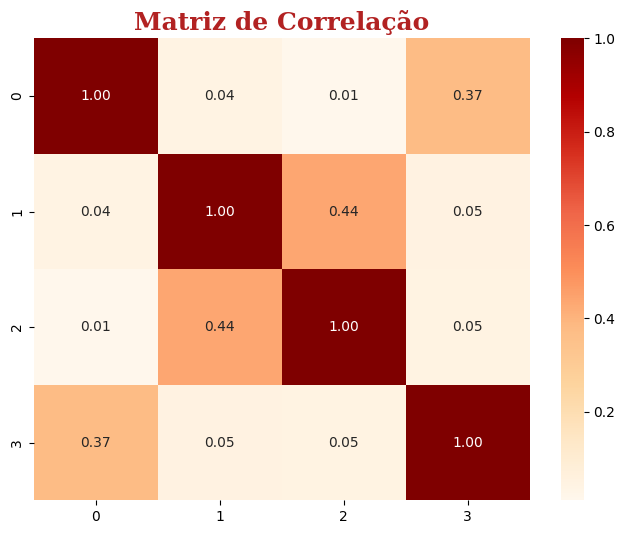

Número de classes (Sturges): 13


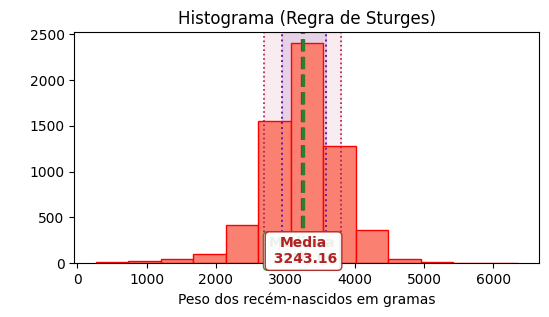

Distância Média/Mediana: -11.84
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



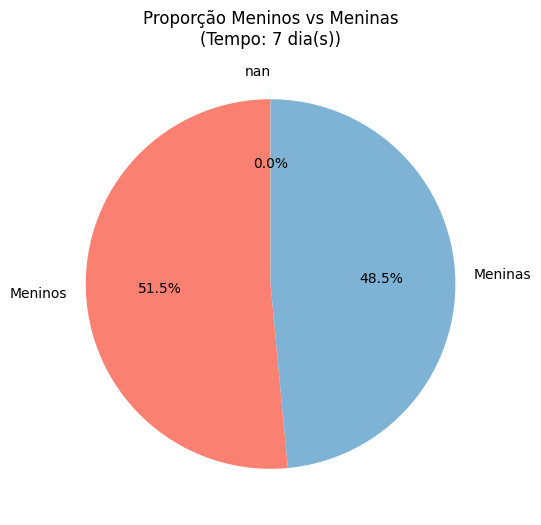

************************************************************************************************************************


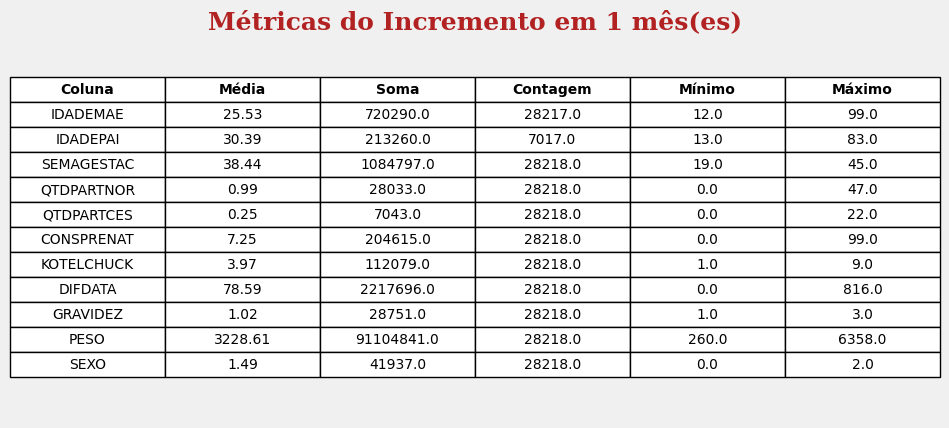

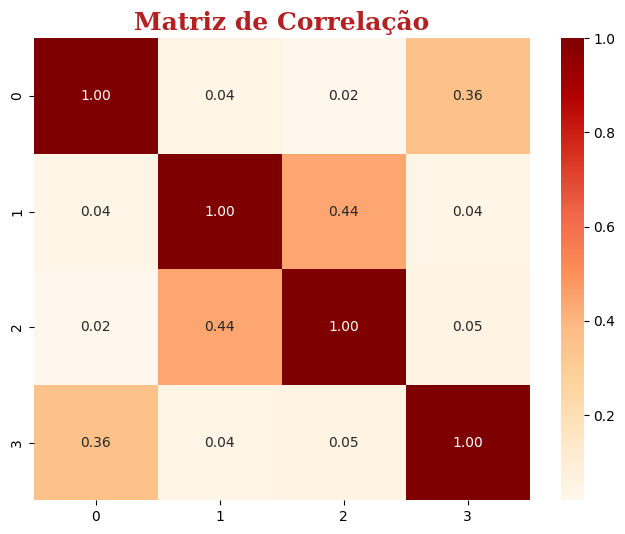

Número de classes (Sturges): 15


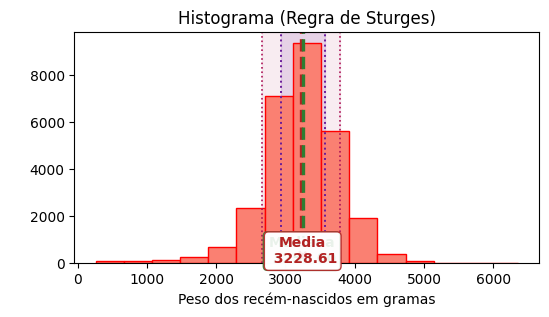

Distância Média/Mediana: -21.39
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



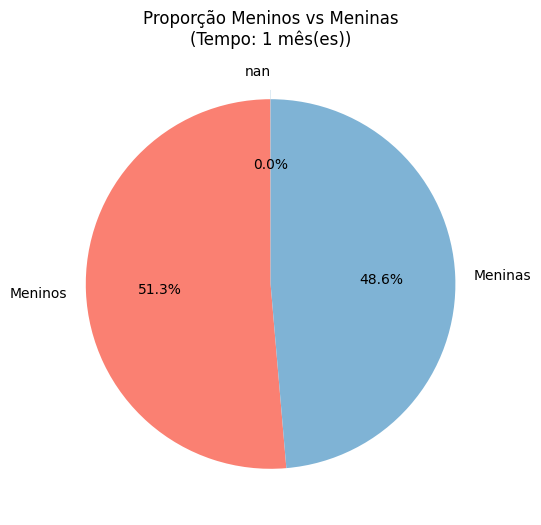

************************************************************************************************************************
**************************************************

Tempo total de processamento: 6.84 min
**************************************************

Memória inicial: 4464.75 MB
Memória final: 4536.89 MB
Memória total utilizada no processo: 72.14 MB
**************************************************



In [45]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = ddf_limpo["DTNASC"].min().compute() 

for tempo in intervalos_medianos:
    data_limite = data_inicio + tempo
    
    df_incremento = ddf_limpo[ddf_limpo['DATA_HORA_NASC'] <= data_limite]
    
    info = metricas_dask(df_incremento, tempo) 
    grafico_de_correlacao_dask(df_incremento, tempo) # Exemplo de nome
    grafico_de_sturges_dask(df_incremento, tempo)    # Exemplo de nome
    grafico_de_pizza_dask(df_incremento, tempo)      # Exemplo de nome
    
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo_total = fim - inicio
memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append({
    "Biblioteca" : "Dask",
    "Ação" : "Operações e gráficos: 1 semana a 1 mes",
    "Tempo" : tempo_total,
    "Memória Utilizada": abs(memoria_fim - memoria_inicio)
})

print(f'{"*"*50}\n')
if(tempo_total < 60):
    print(f'Tempo total de processamento: {tempo_total:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo_total/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

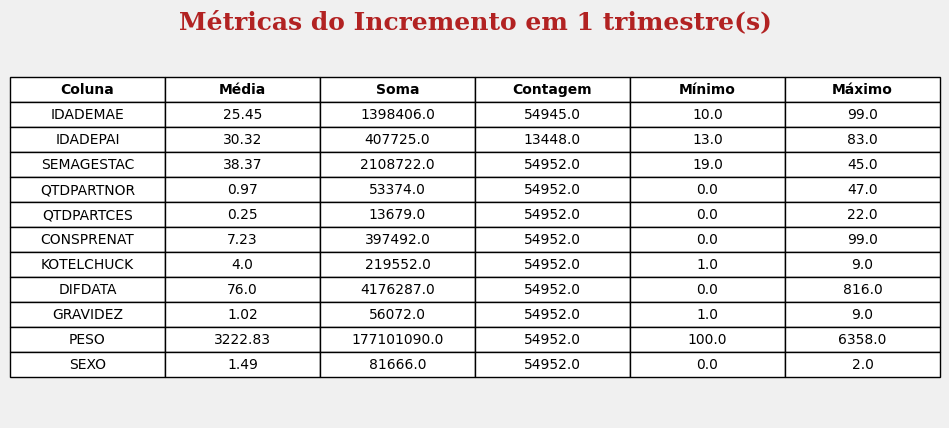

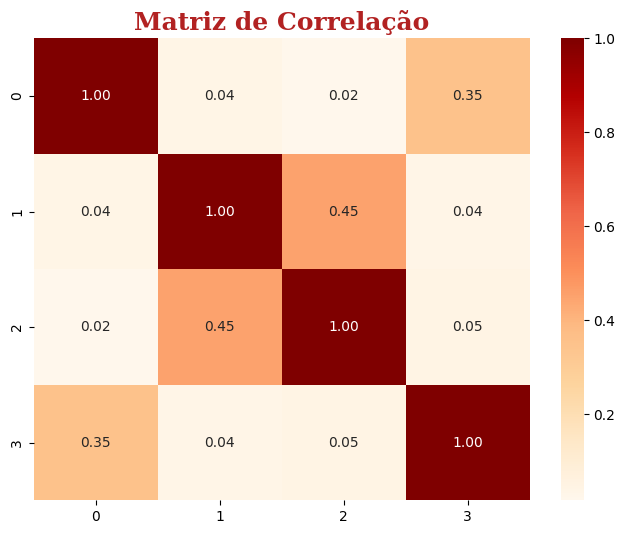

Número de classes (Sturges): 16


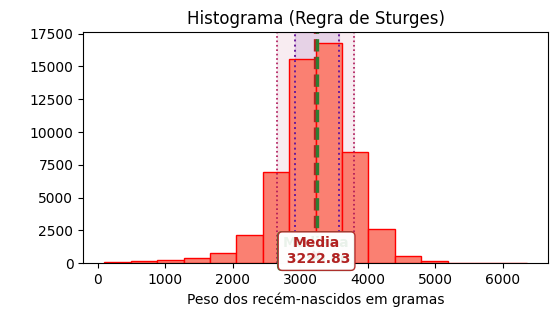

Distância Média/Mediana: -27.17
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



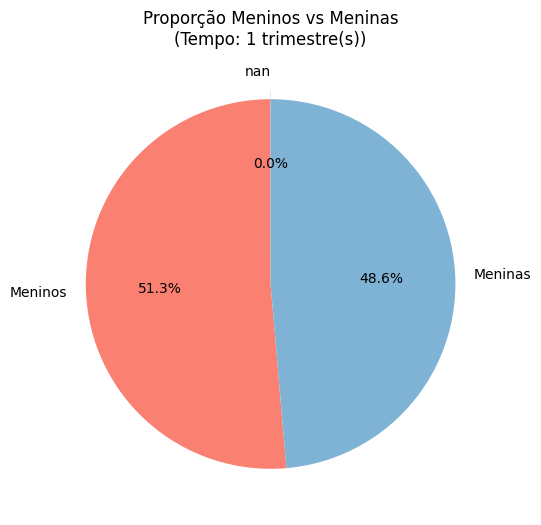

************************************************************************************************************************


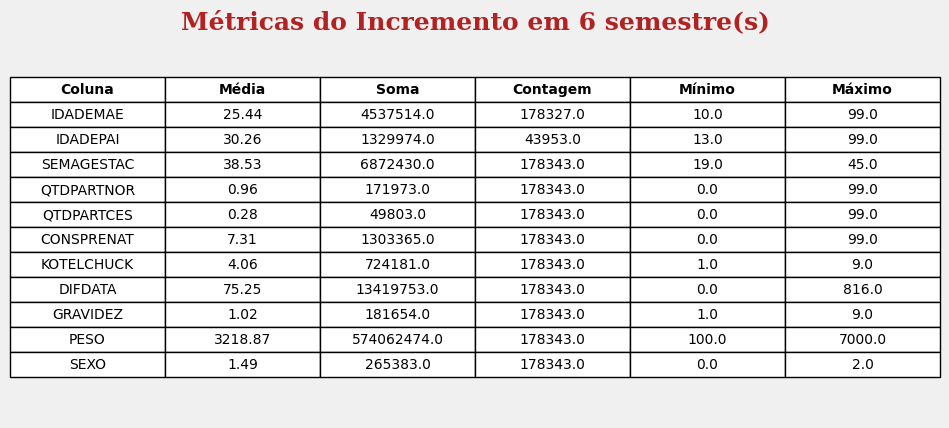

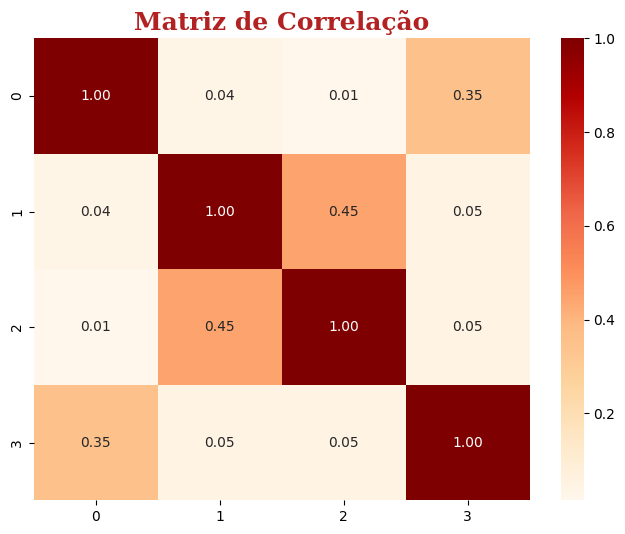

Número de classes (Sturges): 18


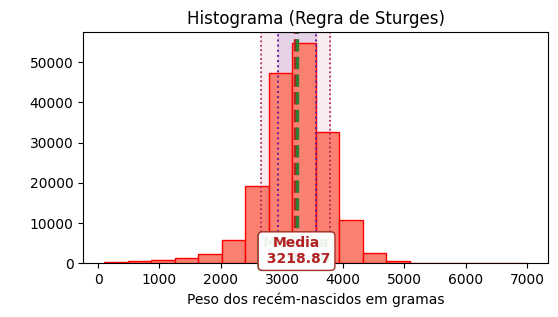

Distância Média/Mediana: -31.13
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



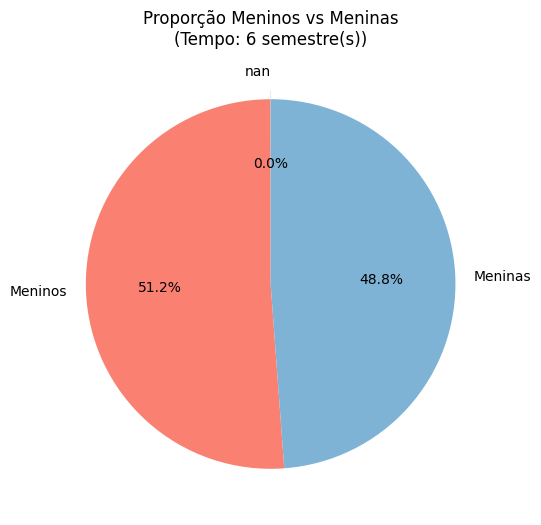

************************************************************************************************************************
**************************************************

Tempo total de processamento: 6.91 min
**************************************************

Memória inicial: 4536.89 MB
Memória final: 4532.22 MB
Memória total utilizada no processo: 4.67 MB
**************************************************



In [46]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = ddf_limpo["DTNASC"].min().compute() 

for tempo in intervalos_finais:
    data_limite = data_inicio + tempo
    
    df_incremento = ddf_limpo[ddf_limpo['DATA_HORA_NASC'] <= data_limite]
    
    info = metricas_dask(df_incremento, tempo) 
    grafico_de_correlacao_dask(df_incremento, tempo) # Exemplo de nome
    grafico_de_sturges_dask(df_incremento, tempo)    # Exemplo de nome
    grafico_de_pizza_dask(df_incremento, tempo)      # Exemplo de nome
    
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo_total = fim - inicio
memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append({
    "Biblioteca" : "Dask",
    "Ação" : "Operações e gráficos: 3 meses a 6 meses",
    "Tempo" : tempo_total,
    "Memória Utilizada": abs(memoria_fim - memoria_inicio)
})

print(f'{"*"*50}\n')
if(tempo_total < 60):
    print(f'Tempo total de processamento: {tempo_total:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo_total/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

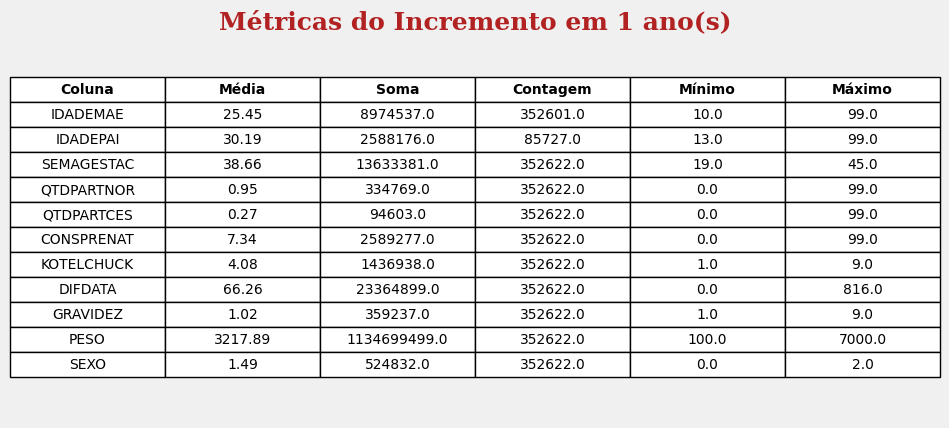

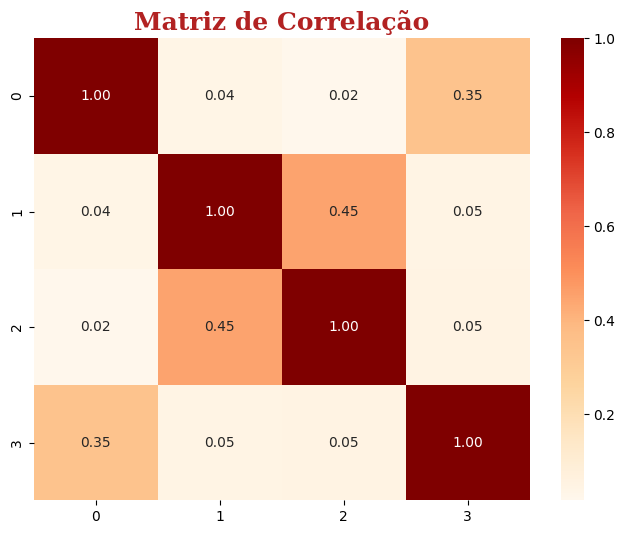

Número de classes (Sturges): 19


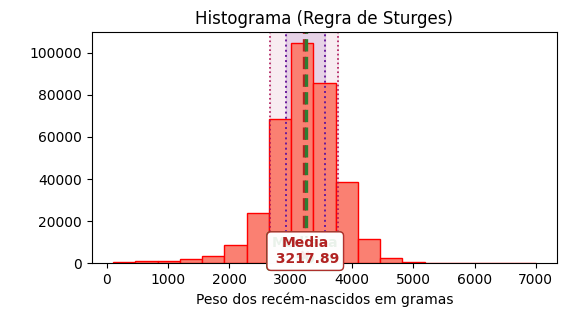

Distância Média/Mediana: -32.11
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



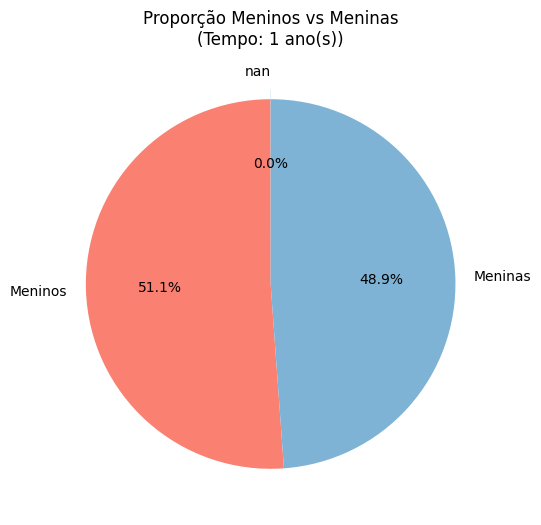

************************************************************************************************************************


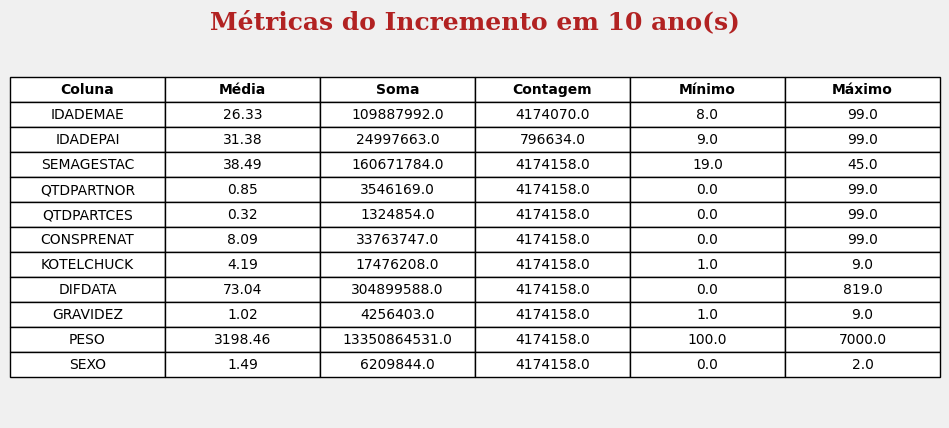

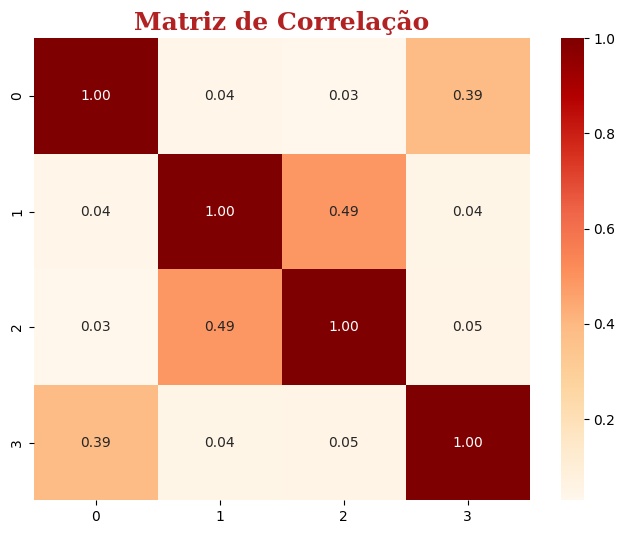

Número de classes (Sturges): 22


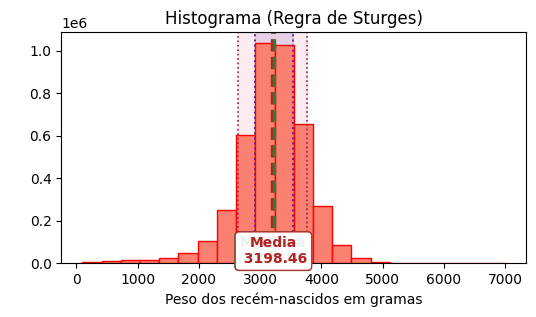

Distância Média/Mediana: -31.54
Assimetria à esquerda - NEGATIVA!
________________________________________________________________________________________________________________________



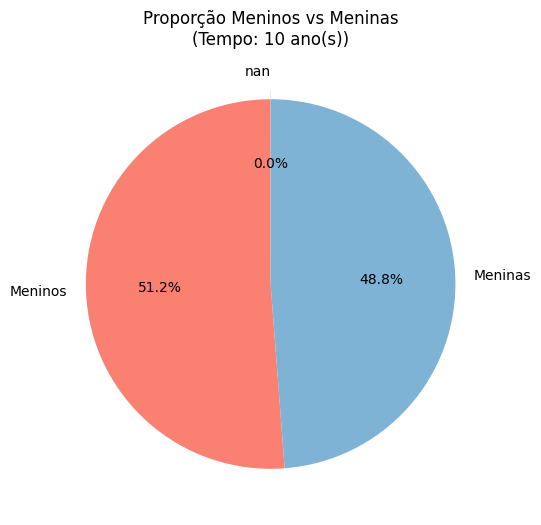

************************************************************************************************************************
**************************************************

Tempo total de processamento: 7.18 min
**************************************************

Memória inicial: 4532.23 MB
Memória final: 4627.90 MB
Memória total utilizada no processo: 95.67 MB
**************************************************



In [47]:
process = psutil.Process(os.getpid())

inicio = time.perf_counter()
memoria_inicio = process.memory_info().rss / 1024**2  # Em MB

data_inicio = ddf_limpo["DTNASC"].min().compute() 

for tempo in intervalos_alemDoFim:
    data_limite = data_inicio + tempo
    
    df_incremento = ddf_limpo[ddf_limpo['DATA_HORA_NASC'] <= data_limite]
    
    info = metricas_dask(df_incremento, tempo) 
    grafico_de_correlacao_dask(df_incremento, tempo) # Exemplo de nome
    grafico_de_sturges_dask(df_incremento, tempo)    # Exemplo de nome
    grafico_de_pizza_dask(df_incremento, tempo)      # Exemplo de nome
    
    print(f'{"*"*120}')

fim = time.perf_counter()
tempo_total = fim - inicio
memoria_fim = process.memory_info().rss / 1024**2

tabela_de_comparacao.append({
    "Biblioteca" : "Dask",
    "Ação" : "Operações e gráficos: 1 ano a 10 anos(limite)",
    "Tempo" : tempo_total,
    "Memória Utilizada": abs(memoria_fim - memoria_inicio)
})

print(f'{"*"*50}\n')
if(tempo_total < 60):
    print(f'Tempo total de processamento: {tempo_total:.2f}s')
else:
    print(f'Tempo total de processamento: {tempo_total/60:.2f} min')
print(f'{"*"*50}\n')
print(f"Memória inicial: {memoria_inicio:.2f} MB")
print(f"Memória final: {memoria_fim:.2f} MB")
print(f"Memória total utilizada no processo: {abs(memoria_fim - memoria_inicio):.2f} MB")
print(f'{"*"*50}\n')

---

# 3. Comparação de Desempenho, envolvendo as bibliotecas utilizadas em sala

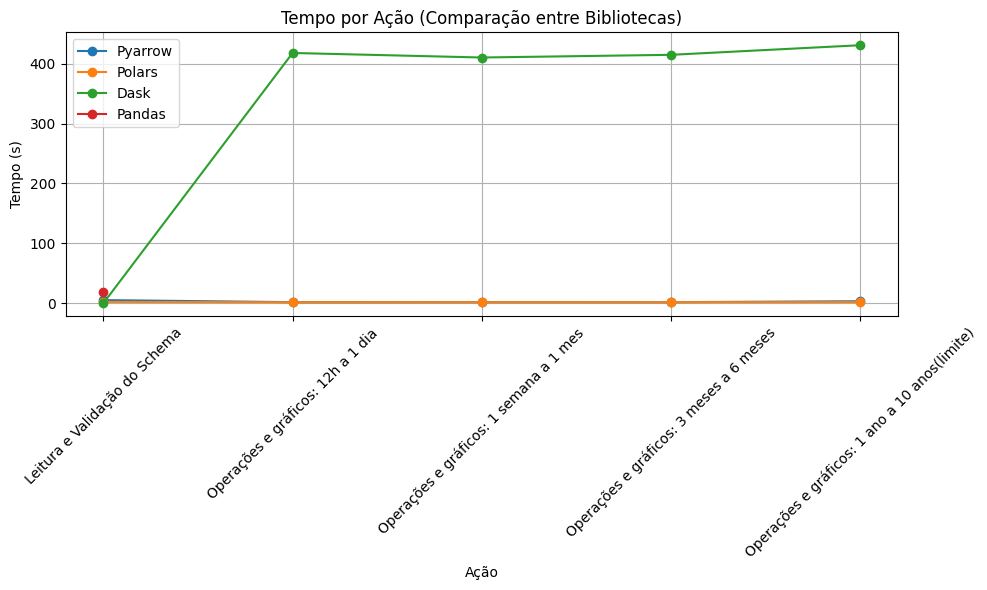

In [52]:
df_comparação = pd.DataFrame(tabela_de_comparacao)

ordem_acoes = [
    "Leitura e Validação de Schema",
    "Operações e gráficos: 12h a 1 dia",
    "Operações e gráficos: 1 semana a 1 mês",
    "Operações e gráficos: 3 meses a 6 meses",
    "Operações e gráficos: 1 ano a 10 anos(limite)"
]

df_filtrado["Ação"] = df_filtrado["Ação"].astype(str)
df_filtrado["Tempo"] = pd.to_numeric(df_filtrado["Tempo"], errors='coerce')

df_filtrado = df_filtrado.dropna(subset=["Ação", "Tempo"])

plt.figure(figsize=(10,6))

for biblioteca in df_comparação["Biblioteca"].unique():
    df_filtrado = df_comparação[df_comparação["Biblioteca"] == biblioteca]
    plt.plot(df_filtrado["Ação"], df_filtrado["Tempo"], marker='o', label=str(biblioteca))

plt.xlabel("Ação")
plt.ylabel("Tempo (s)")
plt.title("Tempo por Ação (Comparação entre Bibliotecas)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("tempo_por_acao.png")
plt.show()

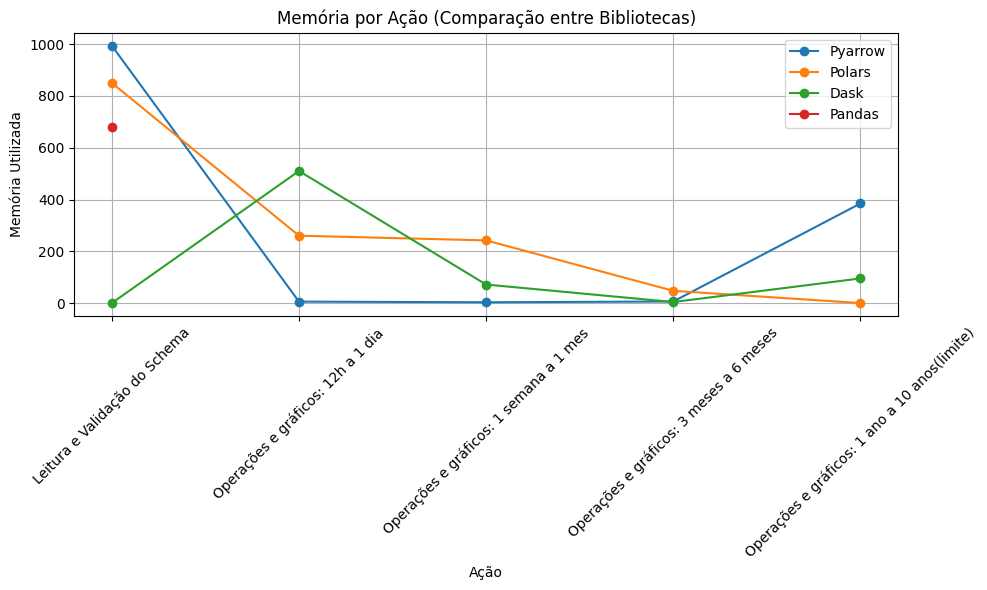

In [54]:

plt.figure(figsize=(10,6))

for biblioteca in df_comparação["Biblioteca"].unique():
    df_filtrado = df_comparação[df_comparação["Biblioteca"] == biblioteca]
    plt.plot(df_filtrado["Ação"], df_filtrado["Memória Utilizada"], marker='o', label=biblioteca)

plt.xlabel("Ação")
plt.ylabel("Memória Utilizada")
plt.title("Memória por Ação (Comparação entre Bibliotecas)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("memoria_por_acao.png")
plt.show()

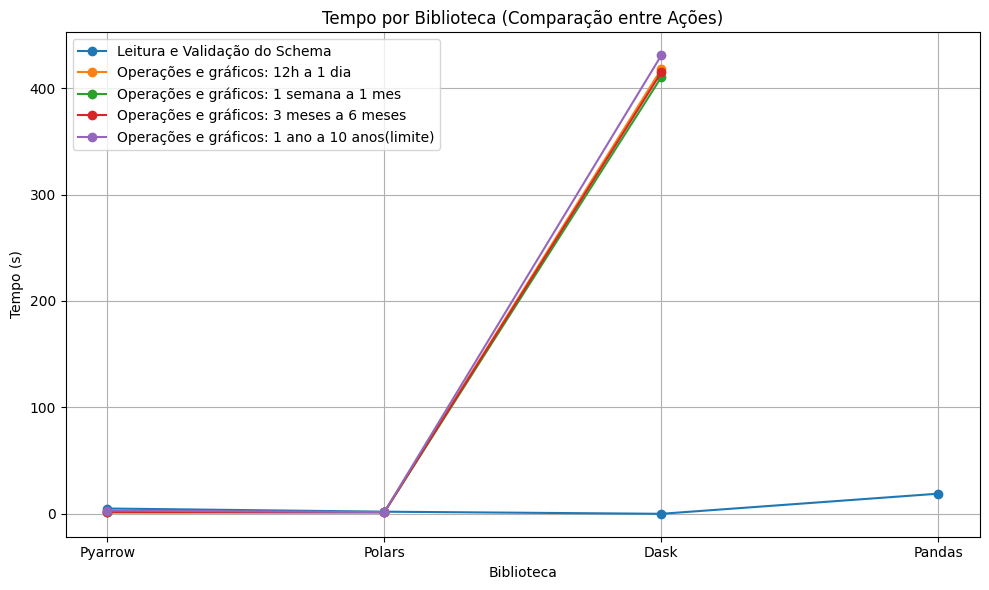

In [55]:
plt.figure(figsize=(10,6))

for acao in df_comparação["Ação"].unique():
    df_filtrado = df_comparação[df_comparação["Ação"] == acao]
    plt.plot(df_filtrado["Biblioteca"], df_filtrado["Tempo"], marker='o', label=acao)

plt.xlabel("Biblioteca")
plt.ylabel("Tempo (s)")
plt.title("Tempo por Biblioteca (Comparação entre Ações)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("tempo_por_biblioteca.png")
plt.show()

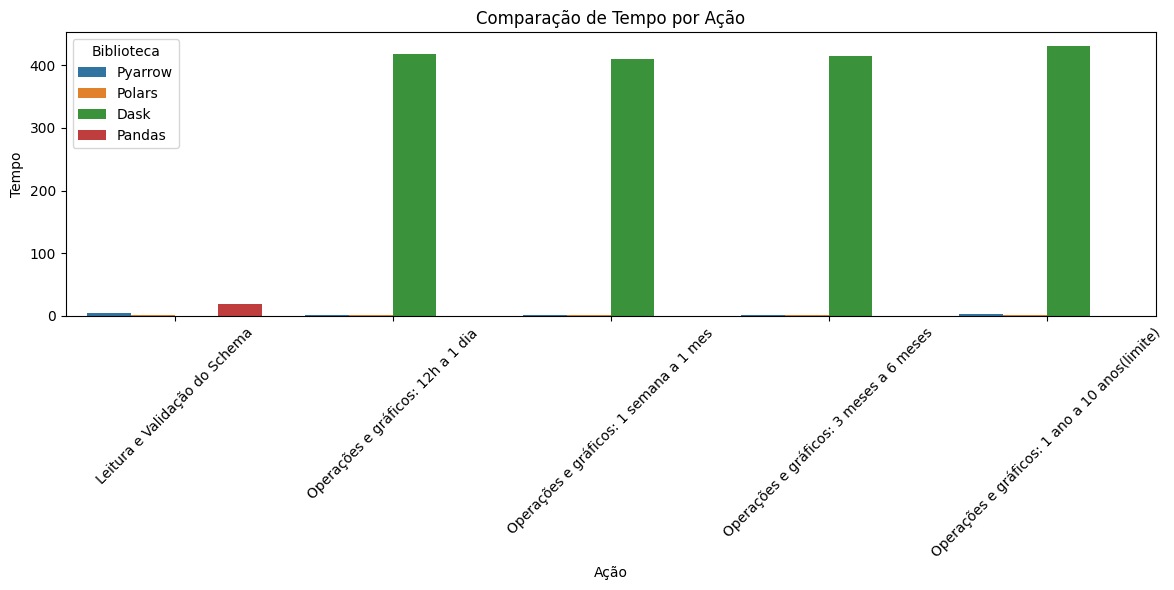

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_comparação,
    x="Ação",
    y="Tempo",
    hue="Biblioteca"
)

plt.xticks(rotation=45)
plt.title("Comparação de Tempo por Ação")
plt.tight_layout()

plt.savefig("barplot_tempo.png")
plt.show()

---
# 4. Processamento paralelo com Dask.

Utilizando pelo menos 3 máquinas (Físicas) diferentes e geração de relatórios de desempenho com variações de numero de workers. Também fazer com aumento gradual, como por exemplo:
* 1 máquina

* 2 máquinas 

* 3 máquinas

**{ as três variar de 2 a N workers }**

In [57]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import Client
import dask.dataframe as dd

In [58]:
IP_DO_SCHEDULER = "10.100.39.215"

client = Client("10.100.39.215:8786")
print(client)
print(client.scheduler_info()["workers"].keys())

<Client: 'tcp://10.100.39.215:8786' processes=2 threads=8, memory=31.01 GiB>
dict_keys(['tcp://10.100.39.215:34903', 'tcp://10.100.39.215:40925'])


In [68]:
import time
import os
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


evolucao = []

# =====================================
# PROCESSAMENTO
# =====================================

def processamento():
    get_dataframe()
    process = psutil.Process(os.getpid())

    inicio = time.perf_counter()
    memoria_inicio = process.memory_info().rss / 1024**2

    data_inicio = ddf_limpo["DTNASC"].min().compute()

    # =====================================
    # CRIA FEATURES
    # =====================================

    ddf_limpo["TIPO_DE_NASCIMENTO"] = (
        ddf_limpo["SEMAGESTAC"] < 37
    ).map({
        True: "prematuro",
        False: "normal"
    })

    ddf_limpo["CATEGORIA_PESO"] = ddf_limpo["PESO"].map_partitions(
        lambda s: pd.cut(
            s,
            bins=[0, 2500, 4000, 6000],
            labels=["baixo_peso", "peso_normal", "peso_alto"]
        )
    )

    # =====================================
    # LOOP TEMPORAL
    # =====================================

    for tempo in intervalos_iniciais:

        data_limite = data_inicio + tempo

        df_incremento = ddf_limpo[
            ddf_limpo["DATA_HORA_NASC"] <= data_limite
        ]

        # =====================================
        # AGREGAÇÃO (IMPORTANTE: NÃO sobrescreve)
        # =====================================

        resultado = (
            df_incremento.groupby(
                ["TIPO_DE_NASCIMENTO", "CATEGORIA_PESO"]
            )
            .size()
            .compute()
            .reset_index(name="QUANTIDADE")
        )

        resultado["INTERVALO"] = tempo

        evolucao.append(resultado)

        print(f"Processado intervalo: {tempo}")

    # =====================================
    # FINALIZA
    # =====================================

    fim = time.perf_counter()
    tempo_total = fim - inicio

    memoria_fim = process.memory_info().rss / 1024**2

    tabela_de_comparacao.append({
        "Biblioteca": "Dask",
        "Tempo": tempo_total,
        "Memória Utilizada": abs(memoria_fim - memoria_inicio)
    })

    print("\nTempo total:", tempo_total)
    print("Memória:", abs(memoria_fim - memoria_inicio))

    return pd.concat(evolucao, ignore_index=True)

In [70]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from dask.distributed import Client
import dask.dataframe as dd

# ==========================================
# CONEXÃO COM O CLUSTER
# ==========================================

client = Client("10.100.39.215:8786")

print(client)

# ==========================================
# MOSTRAR WORKERS ATIVOS
# ==========================================

workers = client.scheduler_info()["workers"]

print("\n=== WORKERS ATIVOS ===")

ips = set()

for worker in workers:

    ip = worker.split("//")[1].split(":")[0]

    ips.add(ip)

    print(worker)

print("\nTotal workers:", len(workers))
print("Total máquinas:", len(ips))

inicio = time.perf_counter()

processamento()

fim = time.perf_counter()

tempo_total = fim - inicio

print(f'{"*"*50}')

print(f"\nTempo total: {tempo_total:.2f} segundos")

relatorio = pd.DataFrame([{
    "maquinas": len(ips),
    "workers": len(workers),
    "tempo": tempo_total
}])

relatorio.to_parquet(
    f"resultado_{len(ips)}maq_{len(workers)}workers.parquet",
    index=False
)

print("\nRelatório salvo.")

<Client: 'tcp://10.100.39.215:8786' processes=5 threads=20, memory=77.53 GiB>

=== WORKERS ATIVOS ===
tcp://10.100.39.214:35687
tcp://10.100.39.214:38863
tcp://10.100.39.214:44301
tcp://10.100.39.215:41487
tcp://10.100.39.215:43261

Total workers: 5
Total máquinas: 2


FileNotFoundError: [Errno 2] No such file or directory: '/home/aluno/Downloads/sinasc_reduzidissima_final.parquet'

---
# Referências
> 
> Link do Dataframe: https://dadosabertos.saude.gov.br/dataset/sistema-de-informacao-sobre-nascidos-vivos-sinasc
>
> Link das documentações:
> * Pyarrow: https://arrow.apache.org/docs/python/parquet.html
> * Dask:
>   * https://docs.dask.org/en/stable/deploying.html
>   * https://docs.dask.org/en/stable/deploying-kubernetes.html
> * Matplotlib: https://matplotlib.org/stable/users/explain/colors/colormaps.html
> 
> Links de retiradas de dúvidas com Gemini:
> * https://gemini.google.com/share/ca16ce21a4ad
> * https://gemini.google.com/share/03d3bfa5343c
> * https://gemini.google.com/share/406b9e8a584f